# Data exploration: Tennessee Eastman Process Simulation Dataset


The **Tennessee Eastman Process (TEP) dataset** provides simulated time-series data representative of industrial chemical processes. It serves as a standard benchmark for evaluating fault detection and diagnostic algorithms. By including both nominal and faulty operational scenarios, the dataset allows for evaluating and comparing the performance of monitoring algorithms.

## Dataset overview (from paper's information)

| Parameter | Value |
| :--- | :--- |
| **Dataset** | Tennessee Eastman Process Simulation Dataset |
| **Domain** | Chemical & Process; Manufacturing & Production |
| **Asset / Process** | Chemical Process |
| **Modality** | Time Series |
| **Task** | Anomaly Detection; Fault Diagnosis; Predictive Maintenance; Process Monitoring |
| **Annotation** | Sample Label; Class Label |
| **Source Type** | Simulation |
| **Access** | Zenodo / Dataverse |


## Data Organization and Features

The dataset consists of four DataFrames (*fault_free_training*, *fault_free_testing*, *faulty_testing*, and *faulty_training*) each stored in its own .RData file.

Each dataframe contains 55 columns:

- **Column 1 ('faultNumber')**: Represents the fault type. It ranges from 1 to 20 in the “Faulty” datasets, while the “FaultFree” datasets only contain fault 0 (indicating normal operating conditions).

- **Column 2 ('simulationRun')**: Represents a different random number generator state from which a full TEP dataset was generated, ranging from 1 to 500. Each run was generated using a unique random seed and the seeds for training and testing datasets were non-overlapping.

- **Column 3 ('sample')** : Represents the sequential time step of the simulation. 
- **Columns 4 to 55** contain the **TEP variables**. Those process variables were sampled every 3 minutes. 



## Set up and loading data

In [1]:
import pyreadr
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

current_dir = Path(os.getcwd())
base_data_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
save_path.mkdir(parents=True, exist_ok=True)




### Loading Data

In [3]:
files_to_load = {
    "fault_free_test": "TEP_FaultFree_Testing.RData",
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "faulty_test": "TEP_Faulty_Testing.RData",
    "faulty_train": "TEP_Faulty_Training.RData"
}


dfs = {}

for key, filename in files_to_load.items():
    csv_path = save_path / f"{key}.csv"
    
    if csv_path.exists():
        try:
            print(f"CSV file {key}.csv exists. Loading from CSV.")
            dfs[key] = pd.read_csv(csv_path)
            continue 
        except Exception as e:
            print(f"Warning: Failed to load {key}.csv ({e}). Proceeding to load from RData.")

    file_path = base_data_path / filename
    if file_path.exists():
        print(f"Loading {filename} (RData) in progress...")
        r_data = pyreadr.read_r(file_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        
        dfs[key].to_csv(csv_path, index=False)
        print(f"File {filename} successfully converted and saved as CSV.")
    else:
        print(f"Error: Source file {filename} not found in {base_data_path}")

CSV file fault_free_test.csv exists. Loading from CSV.
CSV file fault_free_train.csv exists. Loading from CSV.
CSV file faulty_test.csv exists. Loading from CSV.
CSV file faulty_train.csv exists. Loading from CSV.


In [4]:
df_faulty_test = dfs["faulty_test"]
df_faulty_train = dfs["faulty_train"]
df_fault_free_test = dfs["fault_free_test"]
df_fault_free_train = dfs["fault_free_train"]

## Renaming variables and faults

The system uses 8 different materials (4 ingredients, 2 main products, 1 leftover, and 1 non-reactive gas) to create the final products. The process runs through 5 main stages:  
1. Reactor: This is where the raw gases (A, C, D, and E) are turned into liquid products (G and H). 
2. Condenser: This part cools down the hot gases coming out of the reactor.  
3. Separator: This acts like a filter to splitgas and liquid components from the cooled product stream.  
4. Compressor: This pump pushes the separated gases back into the reactor to be used again.  
5. Stripper: This unit handle the efficient cleaning of the products from any unreacted feed components.  

Finally, the system includes a purge vent, which acts as an exhaust to remove the non-reactive product (B) and the unwanted leftover (F) from the system


The original Tennessee Eastman Process (TEP) dataset uses coded identifiers for the process varaibles (e.g., "IDV(1)", "IDV(2)"), which lack intuitive meaning. To improve the readability, We have mapped these labels to their corresponding process fault descriptions.
This nomenclature is based on the reference:
*Montesuma, E. F., Mulas, M., Mboula, F. N., Corona, F., & Souloumiac, A. (2024). Benchmarking Domain Adaptation for Chemical Processes on the Tennessee Eastman Process.*


In [5]:
# Original columns
print(df_faulty_test.columns.to_numpy())

['faultNumber' 'simulationRun' 'sample' 'xmeas_1' 'xmeas_2' 'xmeas_3'
 'xmeas_4' 'xmeas_5' 'xmeas_6' 'xmeas_7' 'xmeas_8' 'xmeas_9' 'xmeas_10'
 'xmeas_11' 'xmeas_12' 'xmeas_13' 'xmeas_14' 'xmeas_15' 'xmeas_16'
 'xmeas_17' 'xmeas_18' 'xmeas_19' 'xmeas_20' 'xmeas_21' 'xmeas_22'
 'xmeas_23' 'xmeas_24' 'xmeas_25' 'xmeas_26' 'xmeas_27' 'xmeas_28'
 'xmeas_29' 'xmeas_30' 'xmeas_31' 'xmeas_32' 'xmeas_33' 'xmeas_34'
 'xmeas_35' 'xmeas_36' 'xmeas_37' 'xmeas_38' 'xmeas_39' 'xmeas_40'
 'xmeas_41' 'xmv_1' 'xmv_2' 'xmv_3' 'xmv_4' 'xmv_5' 'xmv_6' 'xmv_7'
 'xmv_8' 'xmv_9' 'xmv_10' 'xmv_11']


In [6]:
variables_mapping = {
    'XMEAS_1':'A Feed (kscmh)',
    'XMEAS_2':'D Feed (kg/h)',
    'XMEAS_3':'E Feed (kg/h)',
    'XMEAS_4':'A & C Feed (kg/h)',
    'XMEAS_5':'Recycle Flow (kscmh)',
    'XMEAS_6':'Reactor Feed rate (kscmh)',
    'XMEAS_7':'Reactor Pressure (kscmh)',
    'XMEAS_8':'Reactor Level (%)',
    'XMEAS_9':'Reactor Temperature (°C)',
    'XMEAS_10':'Purge Rate (kscmh)',
    'XMEAS_11':'Product Sep Temp (°C)',
    'XMEAS_12':'Product Sep Level (%)',
    'XMEAS_13':'Product Sep Pressure (kPa gauge)',
    'XMEAS_14':'Product Sep Underflow (m^3/h)',
    'XMEAS_15':'Stripper Level (%)',
    'XMEAS_16':'Stripper Pressure (kPa gauge)',
    'XMEAS_17':'Stripper Underflow (m^3/h)',
    'XMEAS_18':'Stripper Temp (°C)',
    'XMEAS_19':'Stripper Steam Flow (kg/h)',
    'XMEAS_20':'Compressor Work (kW)',
    'XMEAS_21':'Reactor Coolant Temp (°C)',
    'XMEAS_22':'Separator Coolant Temp (°C)',
    'XMEAS_23':'Component A to Reactor (mol %)',
    'XMEAS_24':'Component B to Reactor (mol %)',
    'XMEAS_25':'Component C to Reactor (mol %)',
    'XMEAS_26':'Component D to Reactor (mol %)',
    'XMEAS_27':'Component E to Reactor (mol %)',
    'XMEAS_28':'Component F to Reactor (mol %)',
    'XMEAS_29':'Component A in Purge (mol %)',
    'XMEAS_30':'Component B in Purge (mol %)',
    'XMEAS_31':'Component C in Purge (mol %)',
    'XMEAS_32':'Component D in Purge (mol %)',
    'XMEAS_33':'Component E in Purge (mol %)',
    'XMEAS_34':'Component F in Purge (mol %)',
    'XMEAS_35':'Component G in Purge (mol %)',
    'XMEAS_36':'Component H in Purge (mol %)',
    'XMEAS_37':'Component D in Product (mol %)',
    'XMEAS_38':'Component E in Product (mol %)',
    'XMEAS_39':'Component F in Product (mol %)',
    'XMEAS_40':'Component G in Product (mol %)',
    'XMEAS_41':'Component H in Product (mol %)',
    'XMV_1':'D Feed (%)',
    'XMV_2':'E Feed (%)',
    'XMV_3':'A Feed (%)',
    'XMV_4':'A & C Feed (%)',
    'XMV_5':'Compressor recycle valve (%)',
    'XMV_6':'Purge valve (%)',
    'XMV_7':'Separator liquid flow (%)',
    'XMV_8':'Stripper liquid flow (%)',
    'XMV_9':'Stripper steam valve (%)',
    'XMV_10':'Reactor coolant (%)',
    'XMV_11':'Condenser Coolant (%)',
    'XMV_12':'Agitator Speed (%)'
}

In [7]:
def rename_columns(df):
    return df.rename(columns=lambda x: variables_mapping.get(x.upper(), x))

df_faulty_test= rename_columns(df_faulty_test)
df_faulty_train= rename_columns(df_faulty_train)
df_fault_free_test= rename_columns(df_fault_free_test)
df_fault_free_train= rename_columns(df_fault_free_train)

variables = [c for c in df_fault_free_train.columns if c not in ['faultNumber', 'simulationRun', 'sample']]

In [9]:
# Save updated dataframes to CSV, overwriting the old files
dfs_updated = {
    "fault_free_test": df_fault_free_test,
    "fault_free_train": df_fault_free_train,
    "faulty_test": df_faulty_test,
    "faulty_train": df_faulty_train
}

for key, df in dfs_updated.items():
    csv_path = save_path / f"{key}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved {key}.csv with new variables names")

Saved fault_free_test.csv with new variables names
Saved fault_free_train.csv with new variables names
Saved faulty_test.csv with new variables names
Saved faulty_train.csv with new variables names


In [9]:
# New columns
print(df_faulty_test.columns.to_numpy())

['faultNumber' 'simulationRun' 'sample' 'A Feed (kscmh)' 'D Feed (kg/h)'
 'E Feed (kg/h)' 'A & C Feed (kg/h)' 'Recycle Flow (kscmh)'
 'Reactor Feed rate (kscmh)' 'Reactor Pressure (kscmh)'
 'Reactor Level (%)' 'Reactor Temperature (°C)' 'Purge Rate (kscmh)'
 'Product Sep Temp (°C)' 'Product Sep Level (%)'
 'Product Sep Pressure (kPa gauge)' 'Product Sep Underflow (m^3/h)'
 'Stripper Level (%)' 'Stripper Pressure (kPa gauge)'
 'Stripper Underflow (m^3/h)' 'Stripper Temp (°C)'
 'Stripper Steam Flow (kg/h)' 'Compressor Work (kW)'
 'Reactor Coolant Temp (°C)' 'Separator Coolant Temp (°C)'
 'Component A to Reactor (mol %)' 'Component B to Reactor (mol %)'
 'Component C to Reactor (mol %)' 'Component D to Reactor (mol %)'
 'Component E to Reactor (mol %)' 'Component F to Reactor (mol %)'
 'Component A in Purge (mol %)' 'Component B in Purge (mol %)'
 'Component C in Purge (mol %)' 'Component D in Purge (mol %)'
 'Component E in Purge (mol %)' 'Component F in Purge (mol %)'
 'Component G in P

The nomenclature for the fault types used in this analysis is derived from *Santos, P. C., Rocha, M. B., & Krohling, R. A. (2025), Combining SHAP and Causal Analysis for Interpretable Fault Detection in Industrial Processes*, which provides a systematic classification of faults for the Tennessee Eastman Process*. Instead of overwriting the original variables, we have created a new column `faultName`

In [10]:
faults_mapping = {
    0: "Normal (no fault)",
    1: "A/C feed ratio, B composition constant Step",
    2: "B composition, A/C ratio constant Step",
    3: "D feed temperature Step",
    4: "Reactor cooling water inlet temperature Step",
    5: "Condenser cooling water inlet temperature Step",
    6: "A feed loss Step",
    7: "C header pressure loss Step",
    8: "A, B, C feed composition Random variation",
    9: "D feed temperature Random variation",
    10: "C feed temperature Random variation",
    11: "Reactor cooling water inlet temperature Random variation",
    12: "Condenser cooling water inlet temperature Random variation",
    13: "Reaction kinetics Slow drift",
    14: "Reactor cooling water valve Sticking",
    15: "Condenser cooling water valve Sticking",
    16: "Unknown",
    17: "Unknown",
    18: "Unknown",
    19: "Unknown",
    20: "Unknown"
    
}

## Visualization and analysis

The data is organized hierarchically to represent different industrial operating conditions over time:  
- **Fault Number**: In the "Faulty" datasets, there are 20 distinct fault types.
- **Simulation Run**: For each fault type, the process is simulated 500 times, each using a unique random seed to ensure independent and randomized state conditions.  
- **Sample (Time Steps)**: Each simulation run consists of a sequential series of time-stamped observations:  
    - Training Datasets: Each simulation run contains 500 samples, covering a total duration of 25 hours. Faults were introduced after 1 hour of operation.  
    - Testing Datasets: Each simulation run contains 960 samples, covering a total duration of 48 hours. Faults were introduced after 8 hours of operation.  

### Faulty test dataframe

In [17]:
df_faulty_test.head()

,faultNumber,simulationRun,sample,A Feed (kscmh),D Feed (kg/h),E Feed (kg/h),A & C Feed (kg/h),Recycle Flow (kscmh),Reactor Feed rate (kscmh),Reactor Pressure (kscmh),...,E Feed (%),A Feed (%),A & C Feed (%),Compressor recycle valve (%),Purge valve (%),Separator liquid flow (%),Stripper liquid flow (%),Stripper steam valve (%),Reactor coolant (%),Condenser Coolant (%)
0,1,1.0,1,0.25171,3672.4,4466.3,9.5122,27.057,42.473,2705.6,...,54.494,24.527,59.710,22.357,40.149,40.074,47.955,47.300,42.100,15.345
1,1,1.0,2,0.25234,3642.2,4568.7,9.4145,26.999,42.586,2705.2,...,53.269,24.465,60.466,22.413,39.956,36.651,45.038,47.502,40.553,16.063
2,1,1.0,3,0.24840,3643.1,4507.5,9.2901,26.927,42.278,2703.5,...,54.000,24.860,60.642,22.199,40.074,41.868,44.553,47.479,41.341,20.452
3,1,1.0,4,0.25153,3628.3,4519.3,9.3347,26.999,42.330,2703.9,...,53.860,24.553,61.908,21.981,40.141,40.066,48.048,47.440,40.780,17.123
4,1,1.0,5,0.21763,3655.8,4571.0,9.3087,26.901,42.402,2707.7,...,53.307,21.775,61.891,22.412,37.696,38.295,44.678,47.530,41.089,18.681


In [18]:
df_faulty_test.shape

(9600000, 55)

In [30]:
print(df_faulty_test.nunique())

faultNumber                             20
simulationRun                          500
sample                                 960
A Feed (kscmh)                      251494
D Feed (kg/h)                         4612
E Feed (kg/h)                        13484
A & C Feed (kg/h)                    28214
Recycle Flow (kscmh)                  2757
Reactor Feed rate (kscmh)             4067
Reactor Pressure (kscmh)              5477
Reactor Level (%)                    20174
Reactor Temperature (°C)               137
Purge Rate (kscmh)                   64349
Product Sep Temp (°C)                15075
Product Sep Level (%)                 8131
Product Sep Pressure (kPa gauge)      5807
Product Sep Underflow (m^3/h)         9965
Stripper Level (%)                    8383
Stripper Pressure (kPa gauge)         5600
Stripper Underflow (m^3/h)            6035
Stripper Temp (°C)                   19534
Stripper Steam Flow (kg/h)           98157
Compressor Work (kW)                 12854
Reactor Coo

### Faulty train dataframe

In [31]:
df_faulty_train.head()

,faultNumber,simulationRun,sample,A Feed (kscmh),D Feed (kg/h),E Feed (kg/h),A & C Feed (kg/h),Recycle Flow (kscmh),Reactor Feed rate (kscmh),Reactor Pressure (kscmh),...,E Feed (%),A Feed (%),A & C Feed (%),Compressor recycle valve (%),Purge valve (%),Separator liquid flow (%),Stripper liquid flow (%),Stripper steam valve (%),Reactor coolant (%),Condenser Coolant (%)
0,1,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,1,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,1,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,1,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,1,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [7]:
df_faulty_train.shape

(5000000, 55)

In [32]:
print(df_faulty_train.nunique())

faultNumber                             20
simulationRun                          500
sample                                 500
A Feed (kscmh)                      230469
D Feed (kg/h)                         4534
E Feed (kg/h)                        13283
A & C Feed (kg/h)                    27479
Recycle Flow (kscmh)                  2703
Reactor Feed rate (kscmh)             3977
Reactor Pressure (kscmh)              5412
Reactor Level (%)                    19815
Reactor Temperature (°C)               138
Purge Rate (kscmh)                   62298
Product Sep Temp (°C)                14591
Product Sep Level (%)                 7924
Product Sep Pressure (kPa gauge)      5739
Product Sep Underflow (m^3/h)         9711
Stripper Level (%)                    8141
Stripper Pressure (kPa gauge)         5535
Stripper Underflow (m^3/h)            5891
Stripper Temp (°C)                   19176
Stripper Steam Flow (kg/h)           80232
Compressor Work (kW)                 12534
Reactor Coo

### Fault free test dataframe

In [33]:
df_fault_free_test.head()

,faultNumber,simulationRun,sample,A Feed (kscmh),D Feed (kg/h),E Feed (kg/h),A & C Feed (kg/h),Recycle Flow (kscmh),Reactor Feed rate (kscmh),Reactor Pressure (kscmh),...,E Feed (%),A Feed (%),A & C Feed (%),Compressor recycle valve (%),Purge valve (%),Separator liquid flow (%),Stripper liquid flow (%),Stripper steam valve (%),Reactor coolant (%),Condenser Coolant (%)
0,0,1.0,1,0.25171,3672.4,4466.3,9.5122,27.057,42.473,2705.6,...,54.494,24.527,59.710,22.357,40.149,40.074,47.955,47.300,42.100,15.345
1,0,1.0,2,0.25234,3642.2,4568.7,9.4145,26.999,42.586,2705.2,...,53.269,24.465,60.466,22.413,39.956,36.651,45.038,47.502,40.553,16.063
2,0,1.0,3,0.24840,3643.1,4507.5,9.2901,26.927,42.278,2703.5,...,54.000,24.860,60.642,22.199,40.074,41.868,44.553,47.479,41.341,20.452
3,0,1.0,4,0.25153,3628.3,4519.3,9.3347,26.999,42.330,2703.9,...,53.860,24.553,61.908,21.981,40.141,40.066,48.048,47.440,40.780,17.123
4,0,1.0,5,0.21763,3655.8,4571.0,9.3087,26.901,42.402,2707.7,...,53.307,21.775,61.891,22.412,37.696,38.295,44.678,47.530,41.089,18.681


In [10]:
df_fault_free_test.shape

(207252, 55)

In [34]:
print(df_fault_free_test.nunique())

faultNumber                             1
simulationRun                         216
sample                                960
A Feed (kscmh)                      17136
D Feed (kg/h)                        2331
E Feed (kg/h)                        2689
A & C Feed (kg/h)                    5447
Recycle Flow (kscmh)                 1488
Reactor Feed rate (kscmh)            1538
Reactor Pressure (kscmh)              569
Reactor Level (%)                    3528
Reactor Temperature (°C)               18
Purge Rate (kscmh)                   7634
Product Sep Temp (°C)                1691
Product Sep Level (%)                6196
Product Sep Pressure (kPa gauge)      595
Product Sep Underflow (m^3/h)        6334
Stripper Level (%)                   6272
Stripper Pressure (kPa gauge)         513
Stripper Underflow (m^3/h)           3989
Stripper Temp (°C)                   2960
Stripper Steam Flow (kg/h)           6723
Compressor Work (kW)                 1224
Reactor Coolant Temp (°C)         

### Fault free train dataframe

In [35]:
df_fault_free_train.head()

,faultNumber,simulationRun,sample,A Feed (kscmh),D Feed (kg/h),E Feed (kg/h),A & C Feed (kg/h),Recycle Flow (kscmh),Reactor Feed rate (kscmh),Reactor Pressure (kscmh),...,E Feed (%),A Feed (%),A & C Feed (%),Compressor recycle valve (%),Purge valve (%),Separator liquid flow (%),Stripper liquid flow (%),Stripper steam valve (%),Reactor coolant (%),Condenser Coolant (%)
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [36]:
df_fault_free_train.shape

(250000, 55)

In [37]:
print(df_fault_free_train.nunique())

faultNumber                             1
simulationRun                         500
sample                                500
A Feed (kscmh)                      17399
D Feed (kg/h)                        2384
E Feed (kg/h)                        2717
A & C Feed (kg/h)                    5539
Recycle Flow (kscmh)                 1500
Reactor Feed rate (kscmh)            1541
Reactor Pressure (kscmh)              599
Reactor Level (%)                    3609
Reactor Temperature (°C)               18
Purge Rate (kscmh)                   7782
Product Sep Temp (°C)                1745
Product Sep Level (%)                6287
Product Sep Pressure (kPa gauge)      626
Product Sep Underflow (m^3/h)        6428
Stripper Level (%)                   6357
Stripper Pressure (kPa gauge)         518
Stripper Underflow (m^3/h)           4106
Stripper Temp (°C)                   3021
Stripper Steam Flow (kg/h)           6884
Compressor Work (kW)                 1230
Reactor Coolant Temp (°C)         

### Fault distribution for faulty dataset

In [38]:
for key, df in dfs.items():
    if 'faulty' in key.lower(): 
        if 'faultNumber' in df.columns:
            counts = df['faultNumber'].value_counts().sort_index()
            print(f"\nFault distribution for '{key}':")
            print(counts)


Fault distribution for 'faulty_test':
faultNumber
1     480000
2     480000
3     480000
4     480000
5     480000
6     480000
7     480000
8     480000
9     480000
10    480000
11    480000
12    480000
13    480000
14    480000
15    480000
16    480000
17    480000
18    480000
19    480000
20    480000
Name: count, dtype: int64

Fault distribution for 'faulty_train':
faultNumber
1     250000
2     250000
3     250000
4     250000
5     250000
6     250000
7     250000
8     250000
9     250000
10    250000
11    250000
12    250000
13    250000
14    250000
15    250000
16    250000
17    250000
18    250000
19    250000
20    250000
Name: count, dtype: int64


### Cheking the presence of null values

In [39]:
for key, df in dfs.items():
    n_nulls = df.isnull().sum().sum()
    print(f"Dataset '{key}' has {n_nulls} missing values.")

Dataset 'fault_free_test' has 0 missing values.
Dataset 'fault_free_train' has 0 missing values.
Dataset 'faulty_test' has 0 missing values.
Dataset 'faulty_train' has 0 missing values.


### Calculating and visualizing Z-scores to identify variable deviations from the baseline for each fault type.

To identify which process variables are most affected by faults, we establish a normal operating baseline using the fault_free_training dataset. We then quantify the deviation of each fault type from this baseline using Z-scores.
We calculate the average Z-score for each variable across all fault types. The Z-score quantifies the deviation of faulty data from the normal baseline in units of standard deviation ($Z = \frac{\mu_{fault} - \mu_{normal}}{\sigma_{normal}}$). To highlight the most impactful indicators, we identify the top 20 variables exhibiting the highest variance in their Z-scores across different fault types.

In [11]:
baseline_stats = df_fault_free_train[variables].agg(['mean', 'var', 'min', 'max']).T
baseline_stats['range'] = baseline_stats['max'] - baseline_stats['min']

print("Baseline computed for the 52 variables:")
display(baseline_stats)


Baseline computed for the 52 variables:


,mean,var,min,max,range
A Feed (kscmh),0.250482,0.000953,0.122450,0.391740,0.269290
D Feed (kg/h),3663.785706,1156.432346,3511.800000,3808.400000,296.600000
E Feed (kg/h),4508.819790,1537.849196,4336.900000,4683.700000,346.800000
A & C Feed (kg/h),9.347101,0.007348,8.972700,9.729800,0.757100
Recycle Flow (kscmh),26.902196,0.044726,25.951000,27.818000,1.867000
Reactor Feed rate (kscmh),42.337598,0.047748,41.394000,43.257000,1.863000
Reactor Pressure (kscmh),2705.037865,56.634592,2672.300000,2739.100000,66.800000
Reactor Level (%),75.000086,0.293792,72.649000,77.514000,4.865000
Reactor Temperature (°C),120.400022,0.000365,120.310000,120.480000,0.170000
Purge Rate (kscmh),0.337055,0.000157,0.285180,0.394800,0.109620


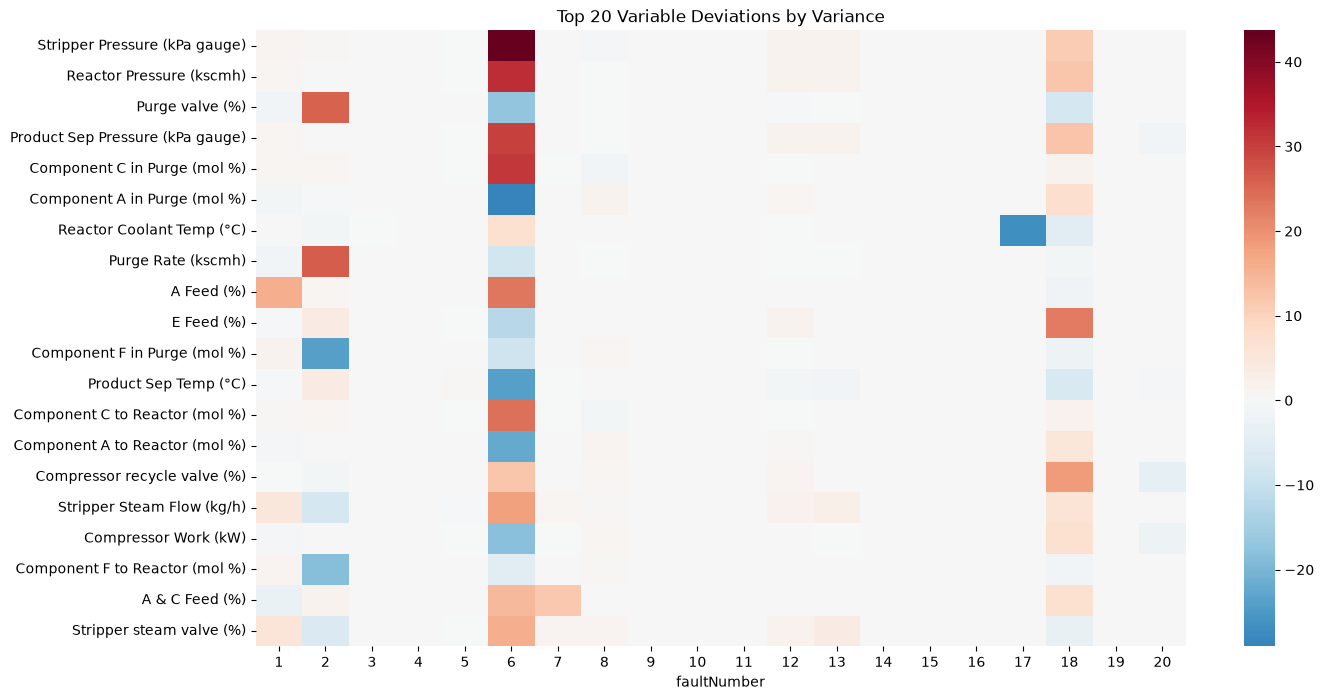

In [13]:
std_normal = df_fault_free_train[variables].std()
mean_normal = df_fault_free_train[variables].mean()

# Aggregate the mean values of process variables for each fault type.
stats_faults = df_faulty_train.groupby('faultNumber')[variables].mean()

z_scores = (stats_faults - mean_normal) / std_normal # Select the top 20 variables with the highest variance among faults
top_vars = z_scores.var().nlargest(20).index

plt.figure(figsize=(15, 8))
sns.heatmap(z_scores[top_vars].T, cmap='RdBu_r', center=0)
plt.title('Top 20 Variable Deviations by Variance')
plt.show()

## Fault Impact Analysis: Fault-Free vs. Faulty
To evaluate the impact of a specific fault on the process dynamics, we perform a comparative analysis between the Fault-Free (normal) and Faulty states. By isolating a single simulation run, we can directly visualize the deviation of a process variable from its nominal baseline. This comparison is critical to identifying the fault's signature and the time lag between fault injection and the first noticeable manifestation in the sensor data.

In [21]:
def compare_fault_free_vs_faulty(fault_numbers, simulation_run, variables=None):
    """
    Compares the time-series trajectory of process variables between the 
    Fault-Free baseline and a specific Faulty simulation run.
    
    Parameters:
    - fault_number (int): The fault ID to compare against the normal state.
    - simulation_run (int): The specific simulation trajectory ID to compare.
    - variables (list, optional): List of process variable names to visualize. 
      If None, defaults to all 52 process variables.
      
    This function generates a grid of subplots superimposing Faulty data onto 
    Fault-Free data. A vertical dashed black line marks the fault injection 
    point (x=20), facilitating the identification of dynamic deviations.
    """
    if variables is None:
        variables = df_faulty_train.columns.drop(['faultNumber', 'simulationRun', 'sample']).tolist() 
    
    if isinstance(fault_numbers, int):
        fault_numbers = [fault_numbers]
        
    # Verifica esistenza dati
    if simulation_run not in df_fault_free_train['simulationRun'].unique():
        print(f"Simulation run {simulation_run} not found.")
        return

    num_features = len(variables)
    num_cols = min(4, num_features)
    num_rows = (num_features // num_cols) + (1 if num_features % num_cols != 0 else 0)
    
    for f_id in fault_numbers:
        # Filter for fault
        fault_name = faults_mapping.get(f_id, f"Fault {f_id}")
        
        print(f'\nComparing fault {fault_name} (fault {f_id}) vs Fault-Free in run {simulation_run}')
        
        data = df_faulty_train[df_faulty_train['faultNumber'] == f_id]
        data = data[data['simulationRun'] == simulation_run]
        
        
        # Prepara il grid
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
      
      
        if num_features == 1:
            axes = [axes]
        else:
            axes = axes.flatten()

        # Estrazione dati
        run_ff = df_fault_free_train[df_fault_free_train['simulationRun'] == simulation_run]
        run_f = df_faulty_train[(df_faulty_train['faultNumber'] == f_id) & 
                                (df_faulty_train['simulationRun'] == simulation_run)]
        
        if run_f.empty:
            print(f"Fault {f_id} or Run {simulation_run} not found.")
            return

        for i, var in enumerate(variables):
            axes[i].plot(run_ff['sample'], run_ff[var], label='Fault Free', color='#1f77b4', alpha=0.6)
            axes[i].plot(run_f['sample'], run_f[var], label=f'Fault {f_id}', color='#e31a1c', alpha=0.6)
            axes[i].axvline(x=20, color='black', linestyle='--', alpha=0.6)
            axes[i].set_title(var, fontsize=10)
            axes[i].set_xlabel('Sample number')
            axes[i].grid(True, linestyle=':', alpha=0.6)
            if i == 0: axes[i].legend()

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()
    



Comparing fault A/C feed ratio, B composition constant Step (fault 1) vs Fault-Free in run 329


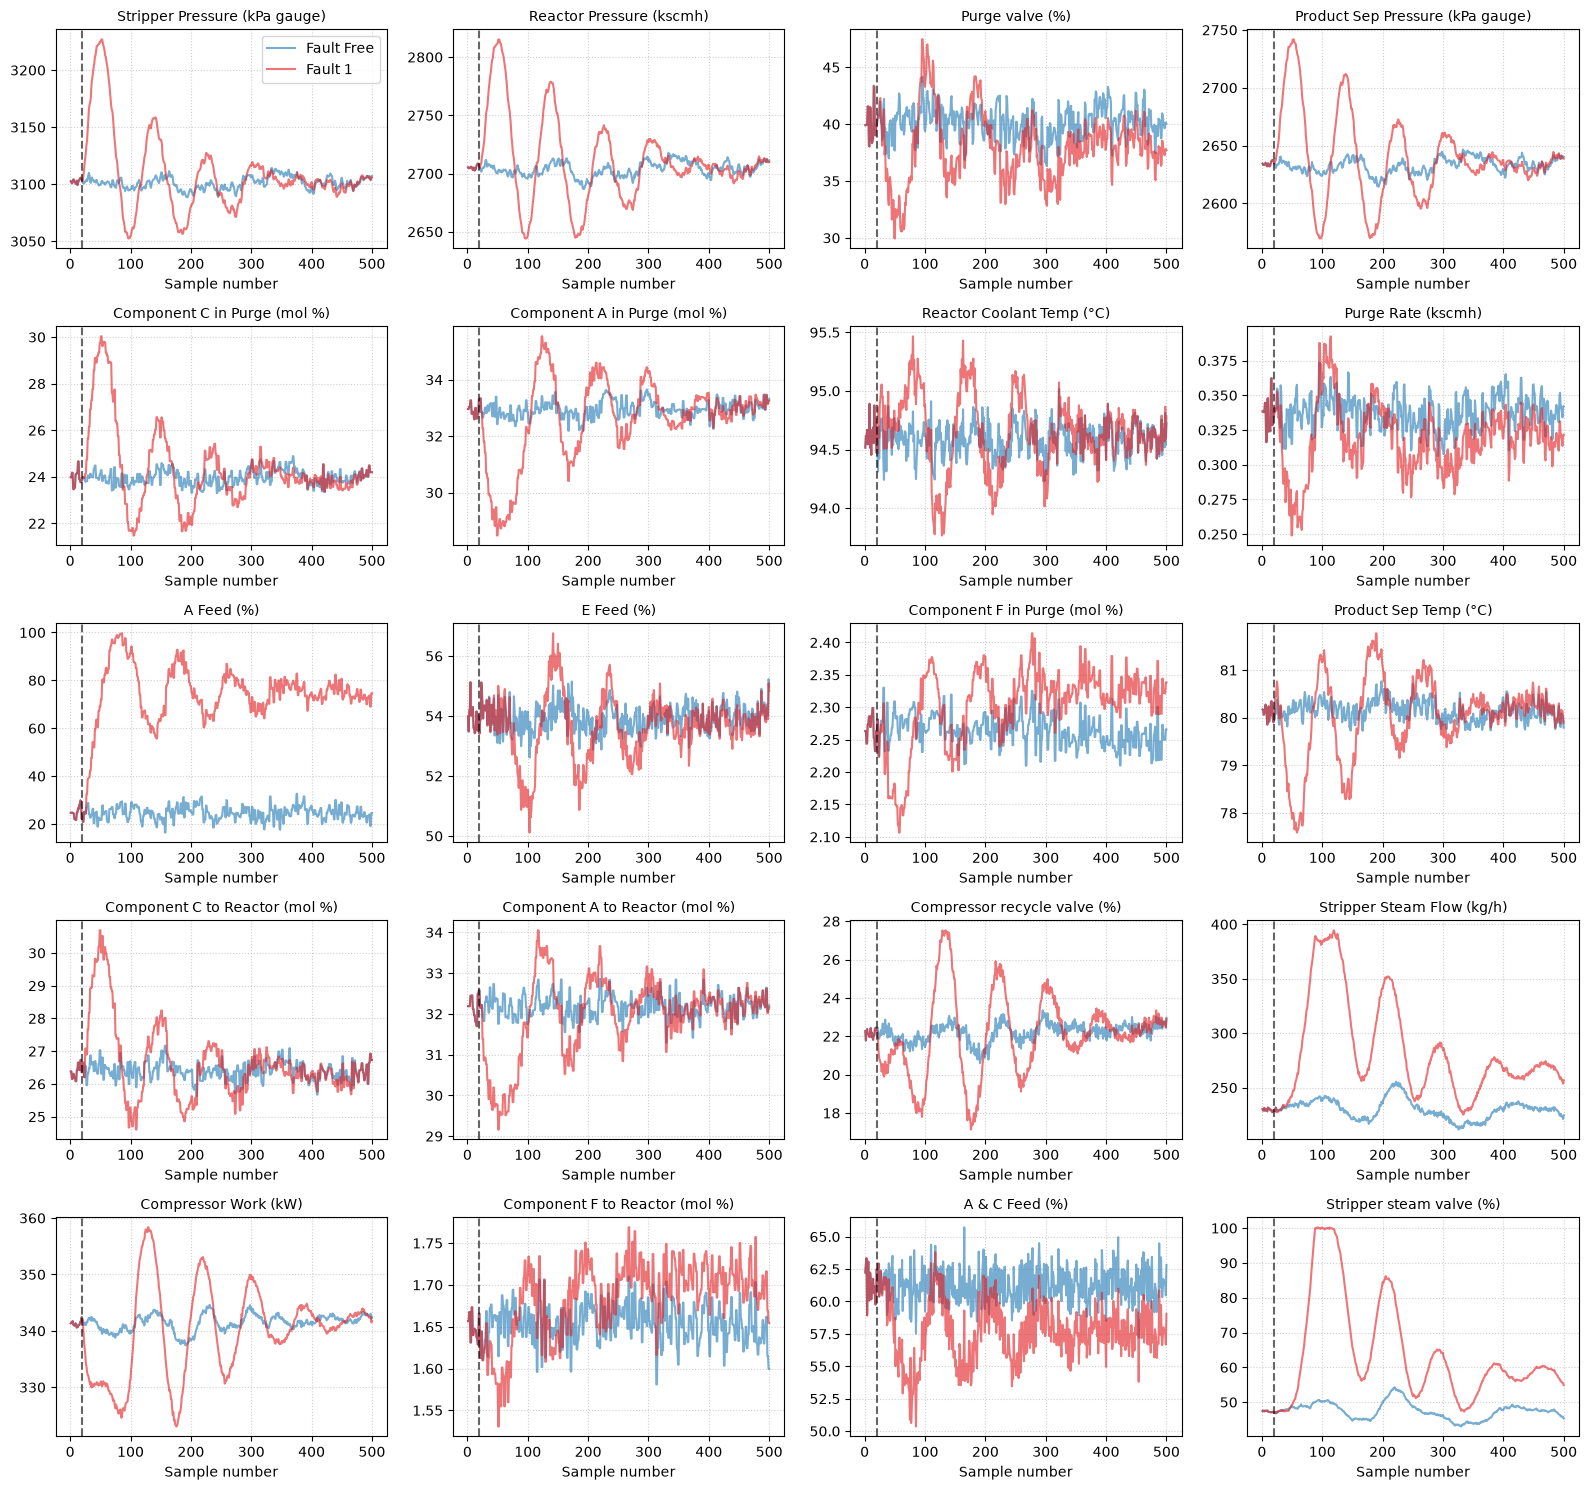


Comparing fault B composition, A/C ratio constant Step (fault 2) vs Fault-Free in run 329


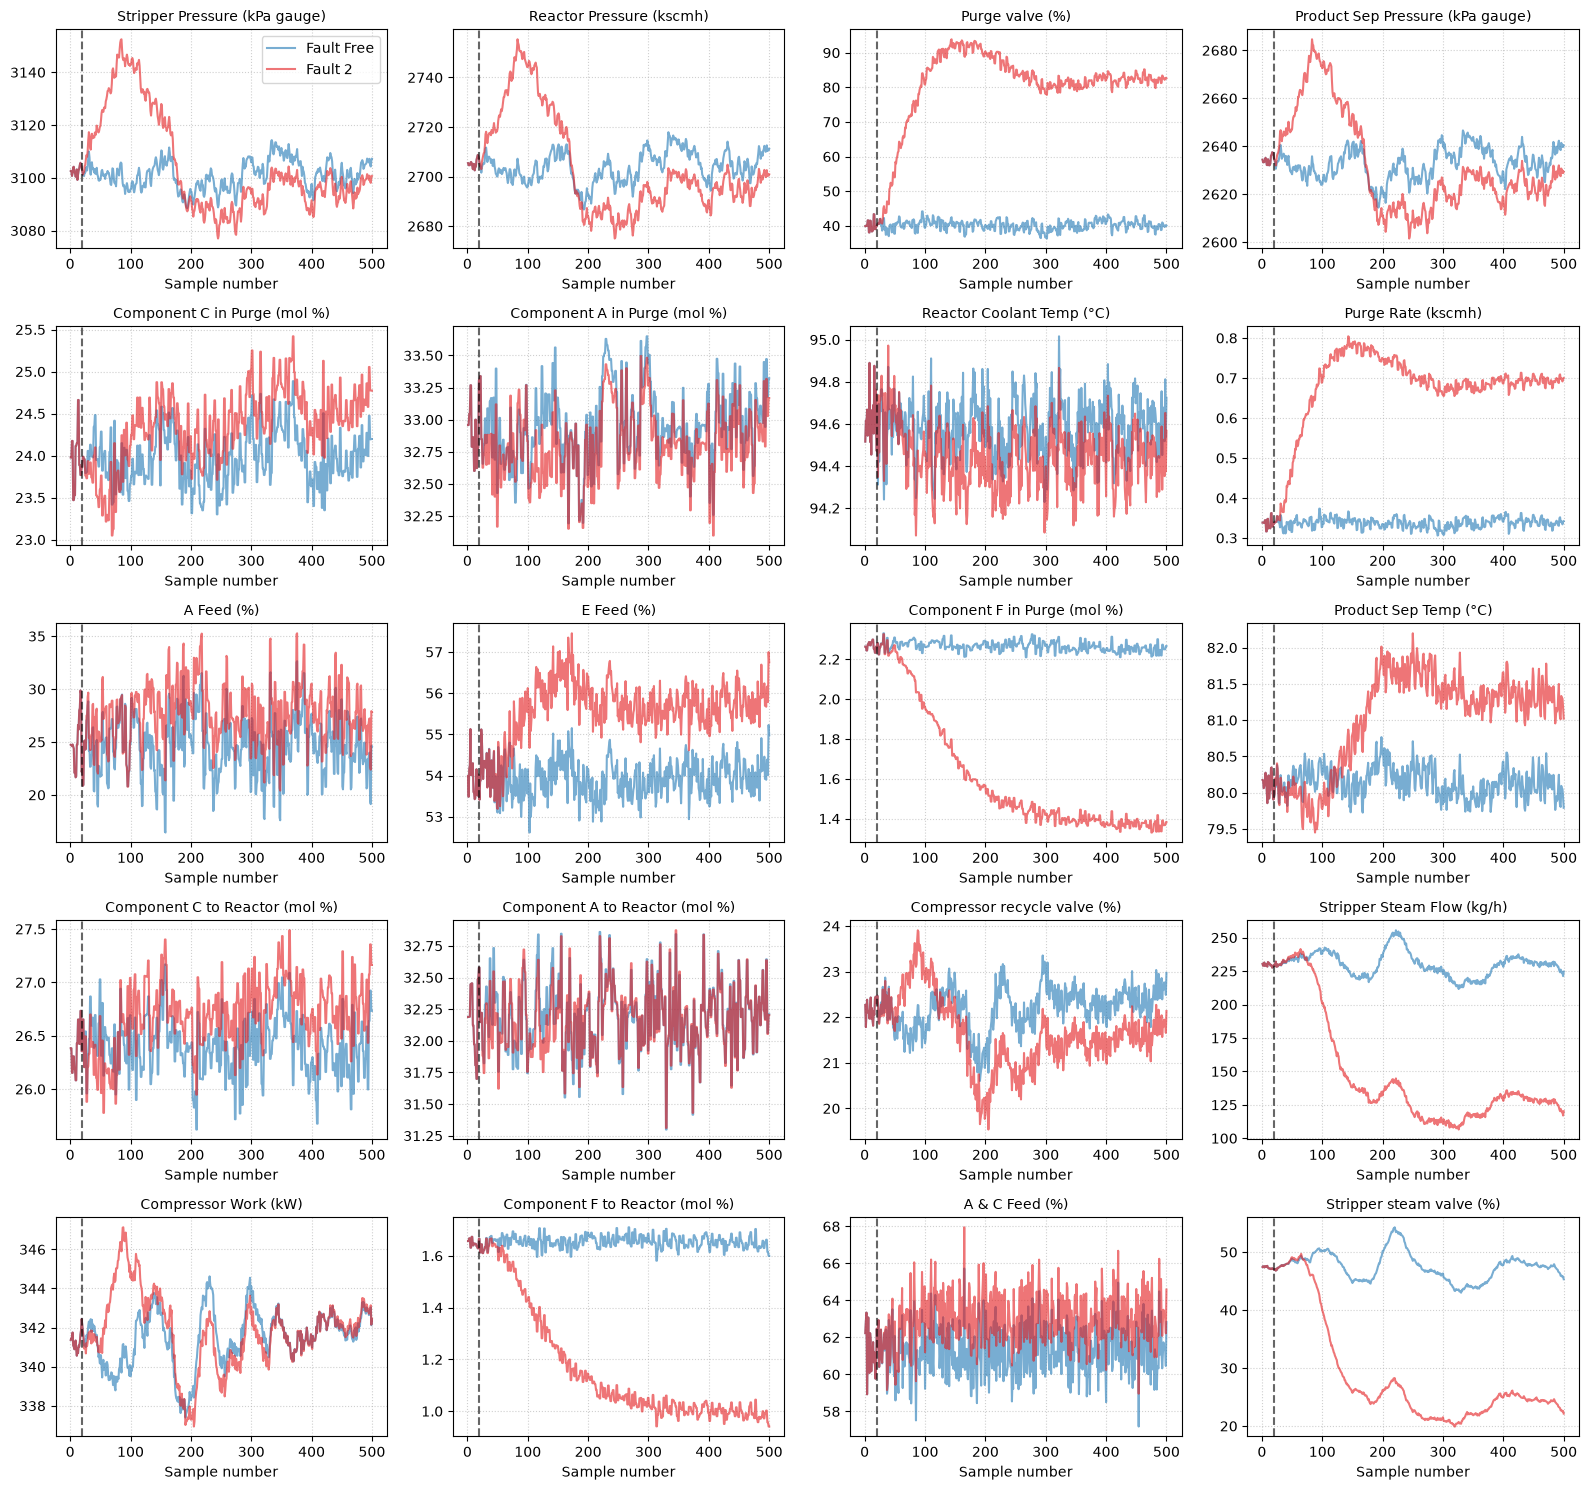


Comparing fault A feed loss Step (fault 6) vs Fault-Free in run 329


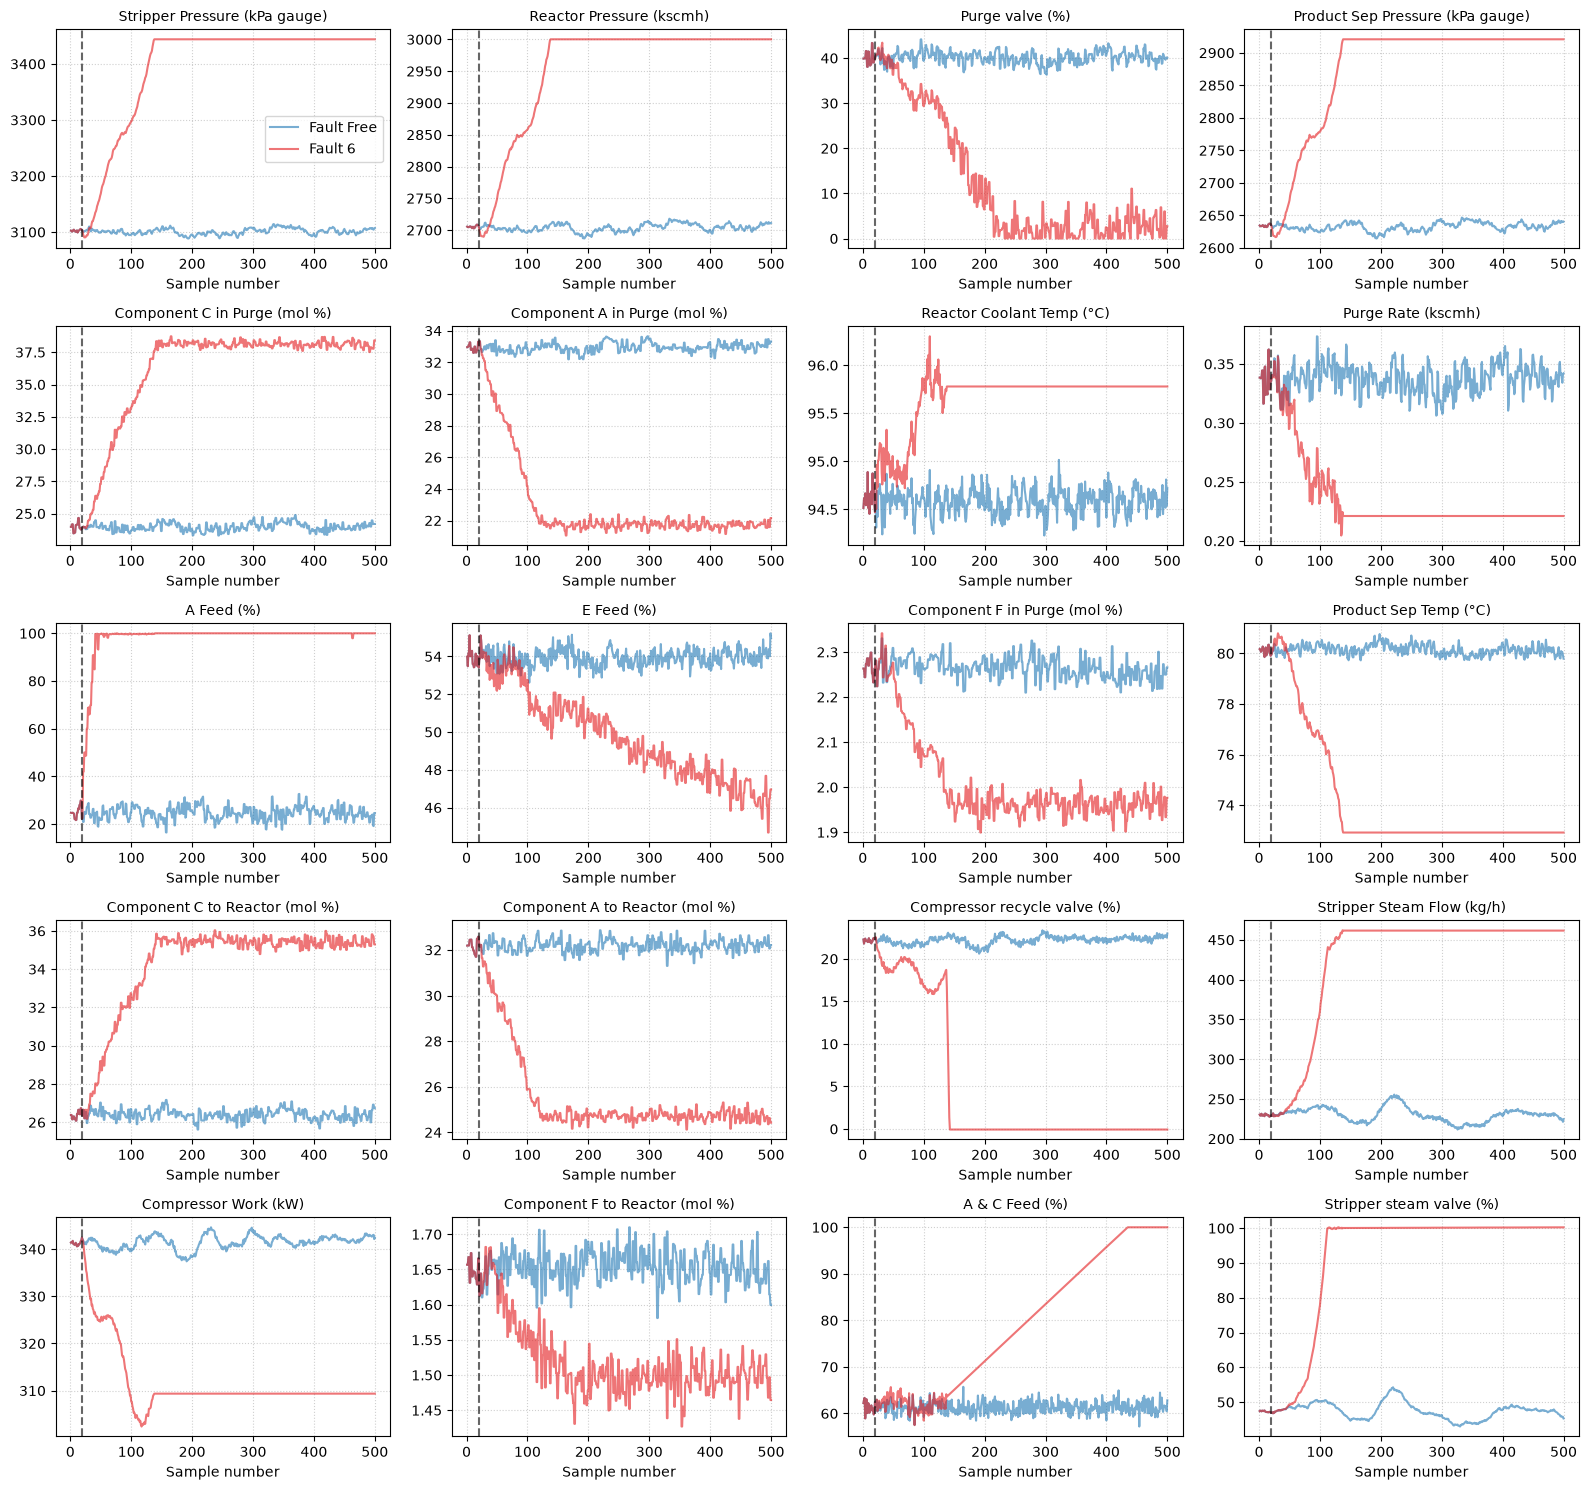


Comparing fault Unknown (fault 18) vs Fault-Free in run 329


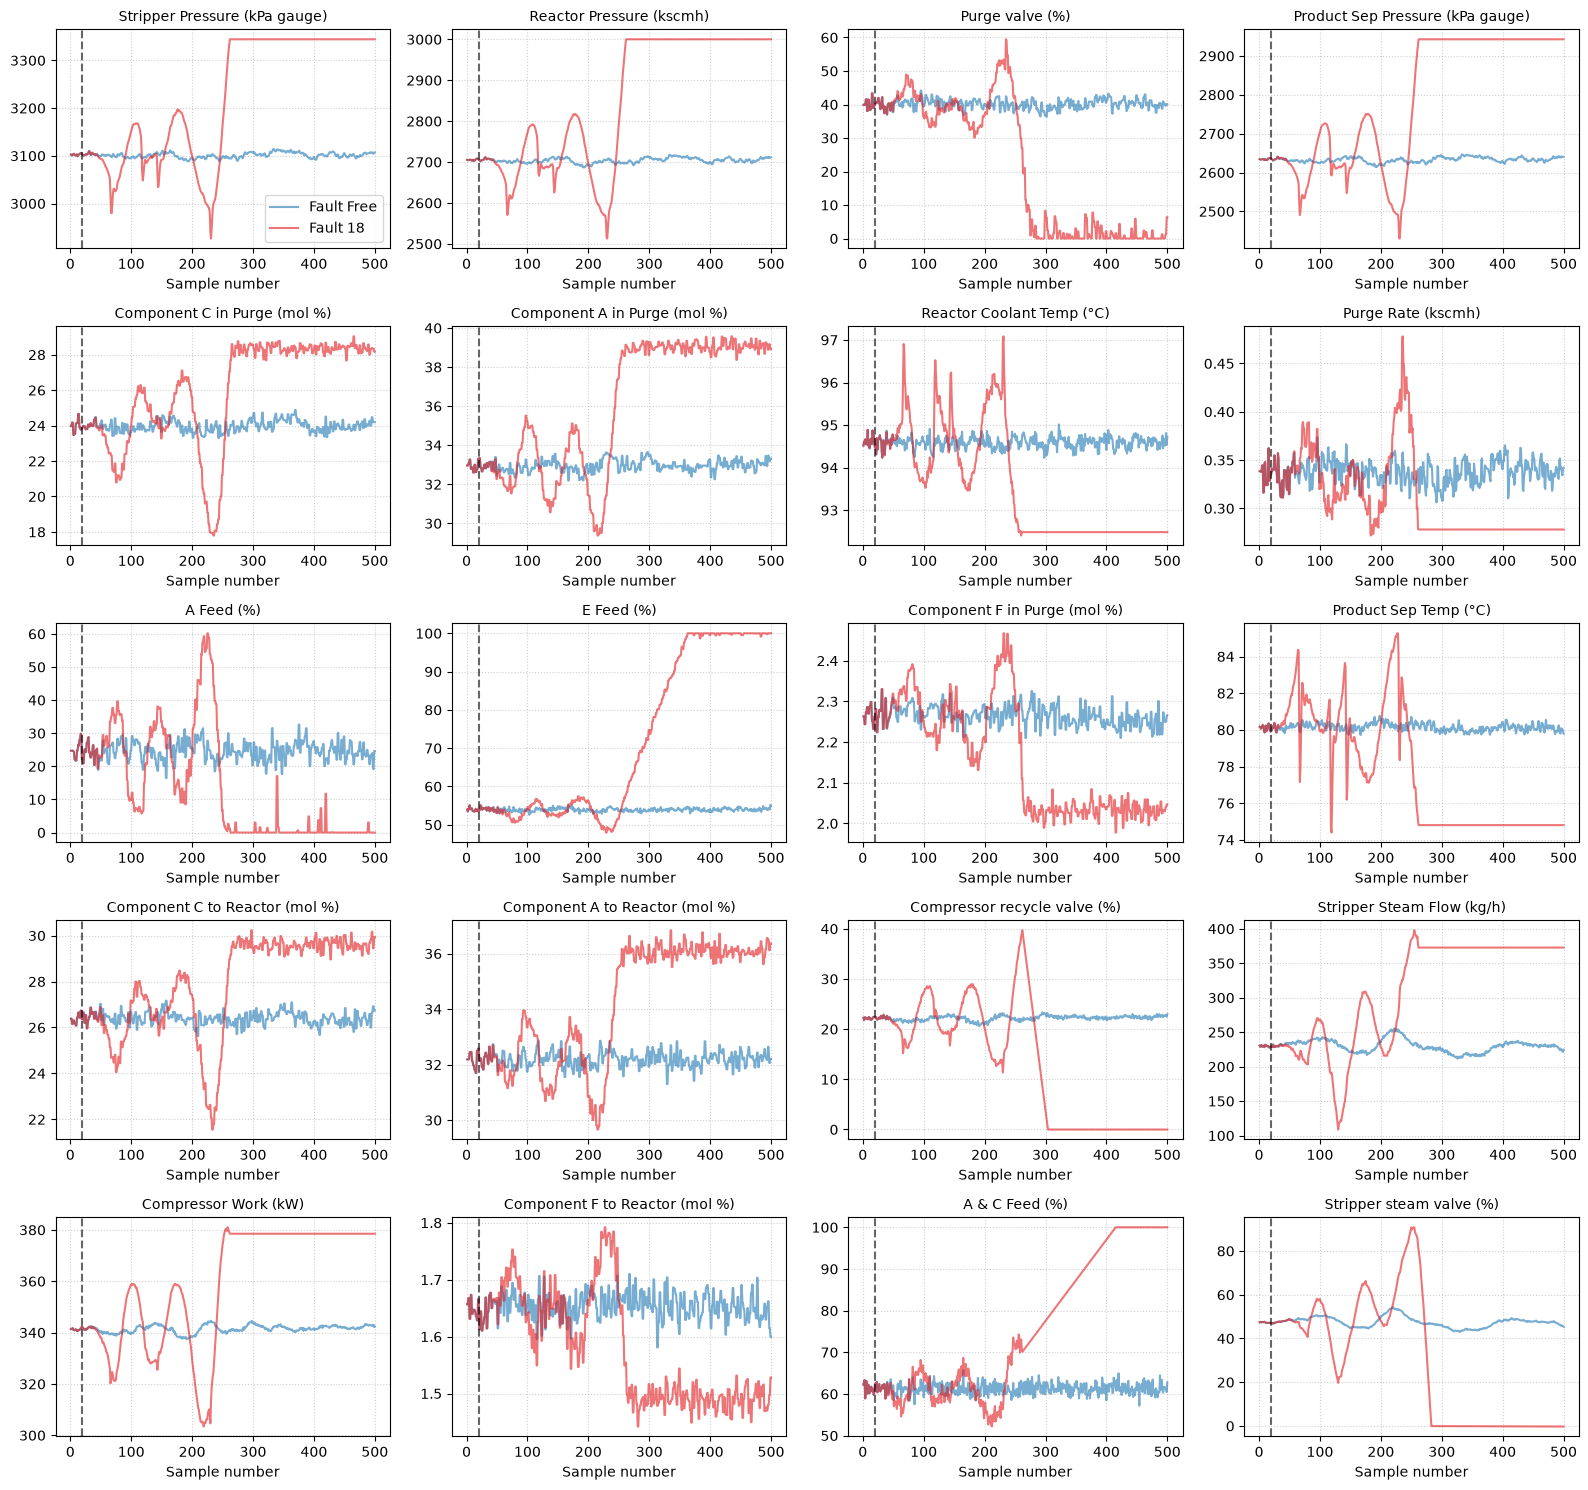

In [22]:
compare_fault_free_vs_faulty(fault_numbers=[1,2,6,18], simulation_run=329, variables=top_vars)

## Fault Consistency Analysis across Simulation Runs
This analysis evaluates the stability and reproducibility of TEP simulations by examining the coherence of process variables across the 500 independent runs. By calculating the standard deviation for each feature at every time step, we can identify whether the system behavior remains consistent under faulty conditions or if the variations in initial random seeds lead to divergent process dynamics. High levels of standard deviation indicate points of high sensitivity or instability in the fault manifestation, whereas low values confirm a highly reproducible fault signature across all simulation iterations.

Processing coherence for Fault 1


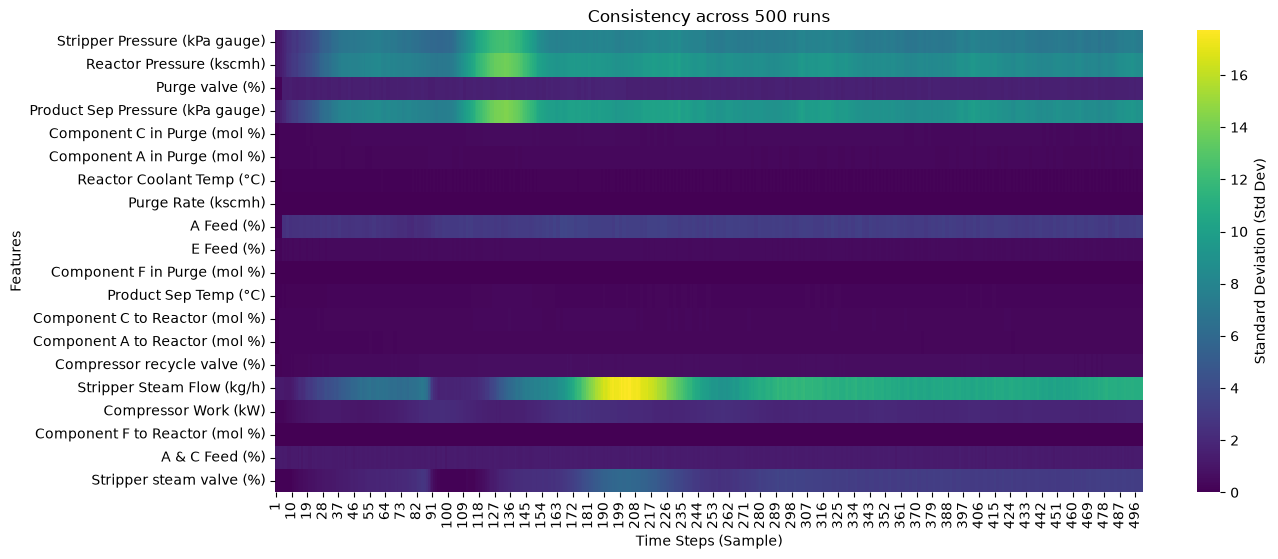

Processing coherence for Fault 2


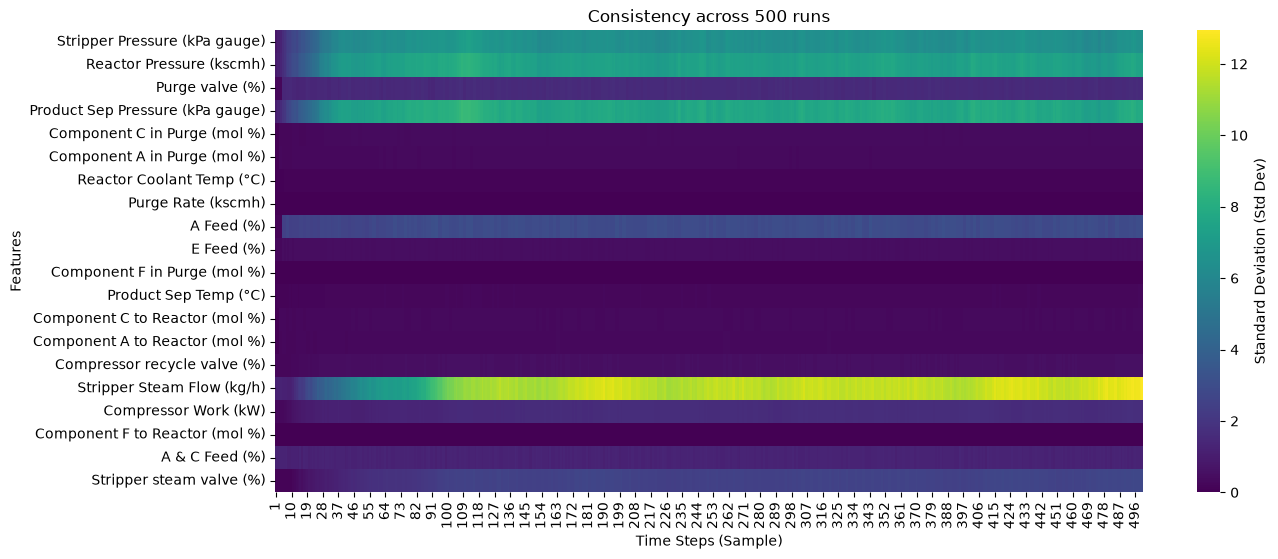

Processing coherence for Fault 5


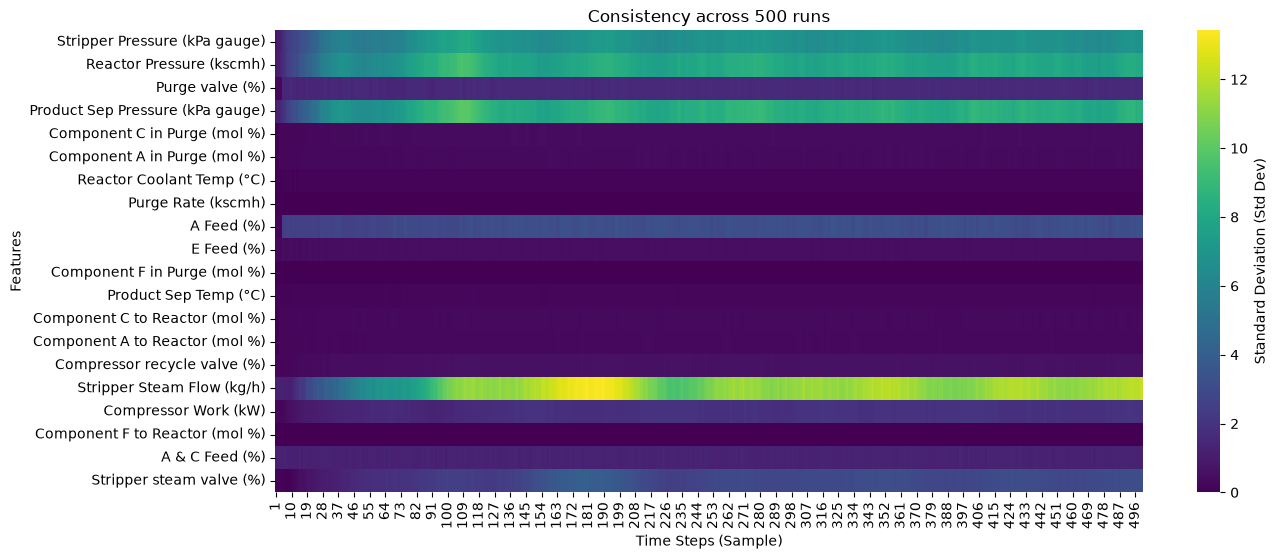

Processing coherence for Fault 6


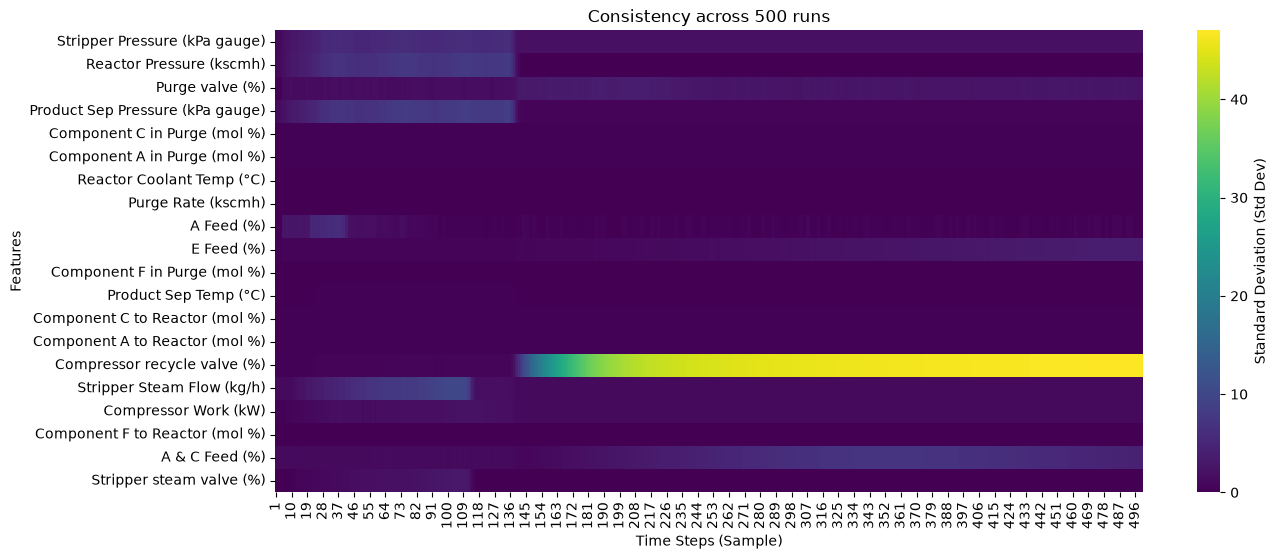

Processing coherence for Fault 10


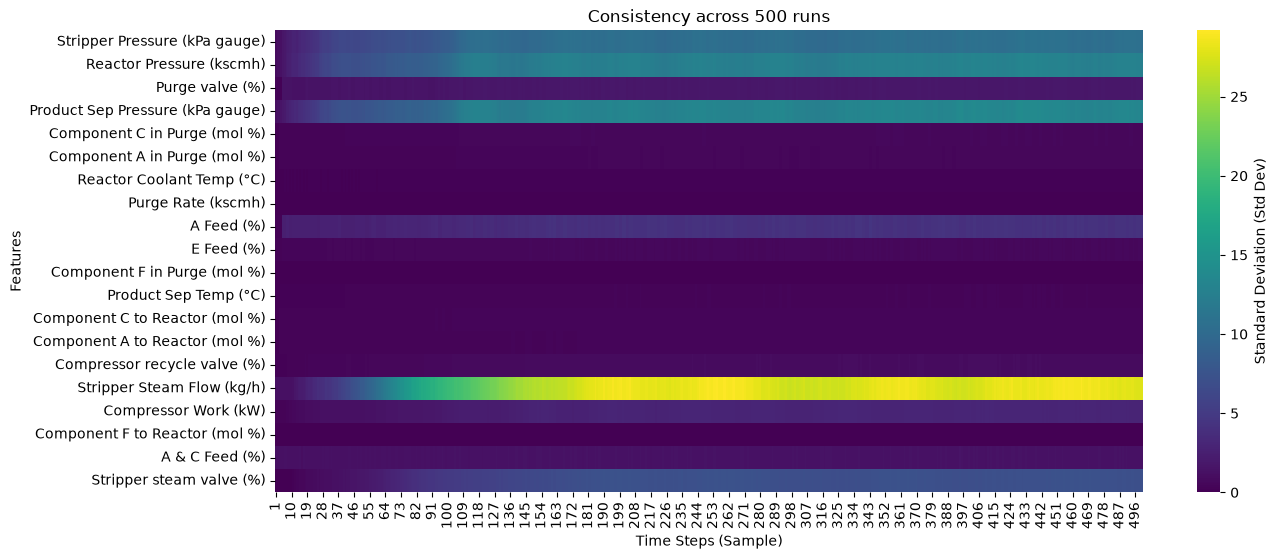

Processing coherence for Fault 18


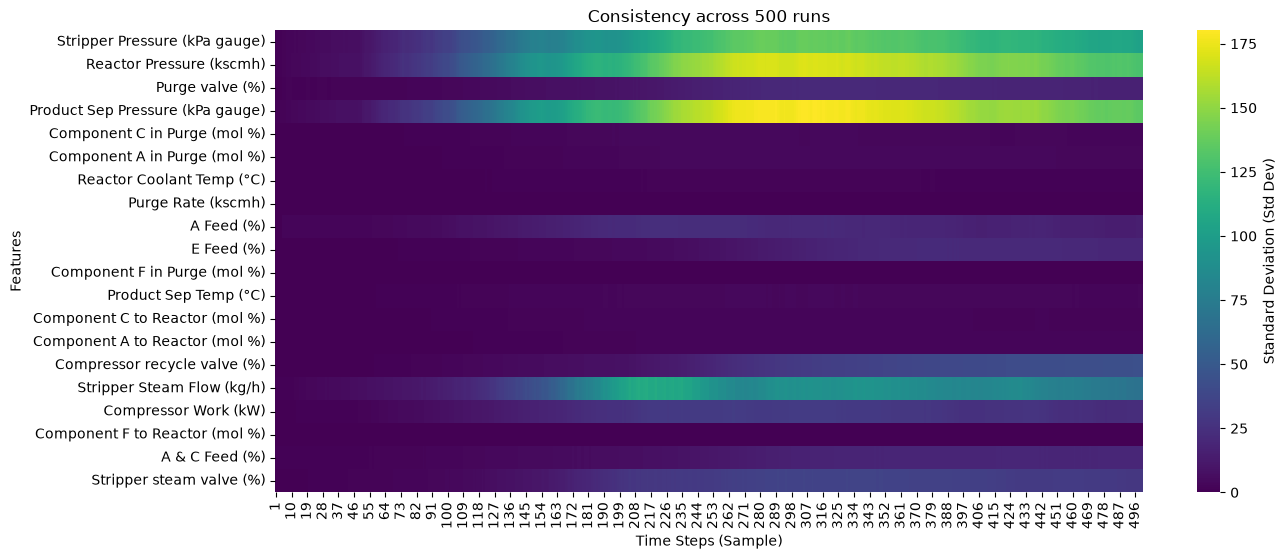

Processing coherence for Fault 20


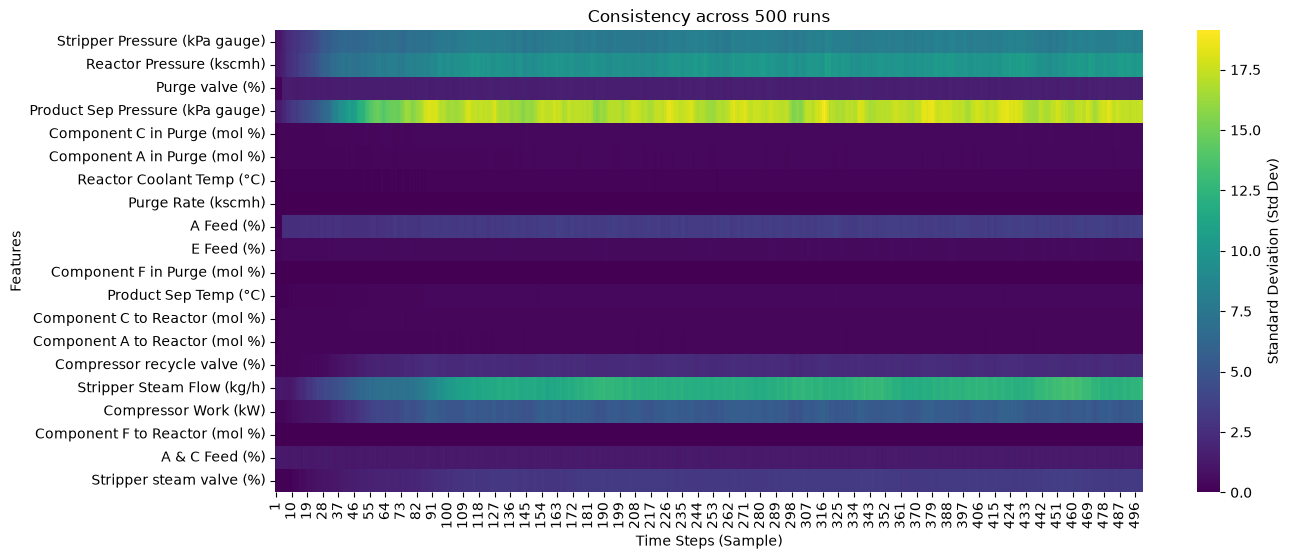

: 

In [ ]:
def get_run_coherence(fault_numbers, variables):
    """
    Analyzes the consistency (coherence) across the 500 simulation runs.
    - If fault_numbers is an int, it converts it to a list.
    - Validates that the provided fault_numbers and variables exist in the dataset.
    """
    # 1. Input Normalization
    if isinstance(fault_numbers, int):
        fault_numbers = [fault_numbers]
    
    # 2. Check variable validity
    invalid_vars = [v for v in variables if v not in df_faulty_train.columns]
    if invalid_vars:
        print(f"Error: The following variables do not exist in the dataset: {invalid_vars}")
        return

    for f_id in fault_numbers:
        # 3. Check fault_number validity
        if f_id not in df_faulty_train['faultNumber'].unique():
            print(f"Error: FaultNumber {f_id} is not present in the dataset.")
            continue
            
        print(f"Processing coherence for Fault {f_id}")
        
        data = df_faulty_train[df_faulty_train['faultNumber'] == f_id]
        
        # 4. Calculate standard deviation for each time step (sample) across all 500 runs
        coherence = data.groupby('sample')[variables].std()
        
        # 5. Visualization
        plt.figure(figsize=(14, 6))
        sns.heatmap(coherence.T, cmap='viridis', 
                    cbar_kws={'label': 'Standard Deviation (Std Dev)'})
        
        plt.title(f'Consistency across 500 runs')
        plt.xlabel('Time Steps (Sample)')
        plt.ylabel('Features')
        plt.show()

# Example usage:
# You can pass a single int or a list
get_run_coherence(fault_numbers=[1, 2, 5, 6, 10, 18, 20], variables=top_vars)

### Time-Series Visualization for Fault Analysis
To gain insights into the process dynamics, we visualize the temporal evolution of process variables during specific fault events. This allows us to observe how the system variables deviate from their normal state following the introduction of a fault.

In [ ]:
def plot_variables(fault_numbers, simulation_run=1, variables=None):
    """
    Visualizes the time-series trajectory of specified process variables for given fault types.
    
    Parameters:
    - fault_numbers (int or list): The fault ID(s) to analyze (e.g., 1 or [1, 2]).
    - simulation_run (int): The specific simulation trajectory ID to plot (default is 1).
    - variables (list, optional): List of process variable names (columns) to plot. 
      If None, the function defaults to all 52 process variables.
    
    The function generates a grid of subplots for each requested fault ID, plotting the 
    variable values over the 'sample' timeline. It includes a vertical dashed red line 
    marking the theoretical fault injection point (x=20 for training data).
    """
    
    if variables is None:
        variables = df_faulty_train.columns.drop(['faultNumber', 'simulationRun', 'sample']).tolist() 
        
    if isinstance(fault_numbers, int):
        fault_numbers = [fault_numbers]
    
    if simulation_run not in df_faulty_train['simulationRun'].unique():
        print(f"Simulation run {simulation_run} not found.")
        return

    num_features = len(variables)
    num_cols = min(4, num_features)
    num_rows = (num_features // num_cols) + (1 if num_features % num_cols != 0 else 0)

    for f_id in fault_numbers:
        fault_name = faults_mapping.get(f_id, f"Fault {f_id}")
        
        print(f'\nAnalysis for {fault_name} (fault {f_id}) in run {simulation_run}')
        # Verifica esistenza fault
        if f_id not in df_faulty_train['faultNumber'].unique():
            
            print(f"Fault {f_id} non trovato, salto.")
            continue
            
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
        axes = axes.flatten()

        run = df_faulty_train[(df_faulty_train['faultNumber'] == f_id) & 
                              (df_faulty_train['simulationRun'] == simulation_run)]

        for i, var in enumerate(variables):
            axes[i].plot(run['sample'], run[var])
            axes[i].axvline(x=20, color='r', linestyle='--', alpha=0.6) # where the fault happens
            axes[i].set_title(var, fontsize=10)
            axes[i].set_xlabel('Sample number')
            axes[i].grid(True, linestyle=':', alpha=0.6)

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()




Analysis for A/C feed ratio, B composition constant Step (fault 1) in run 4


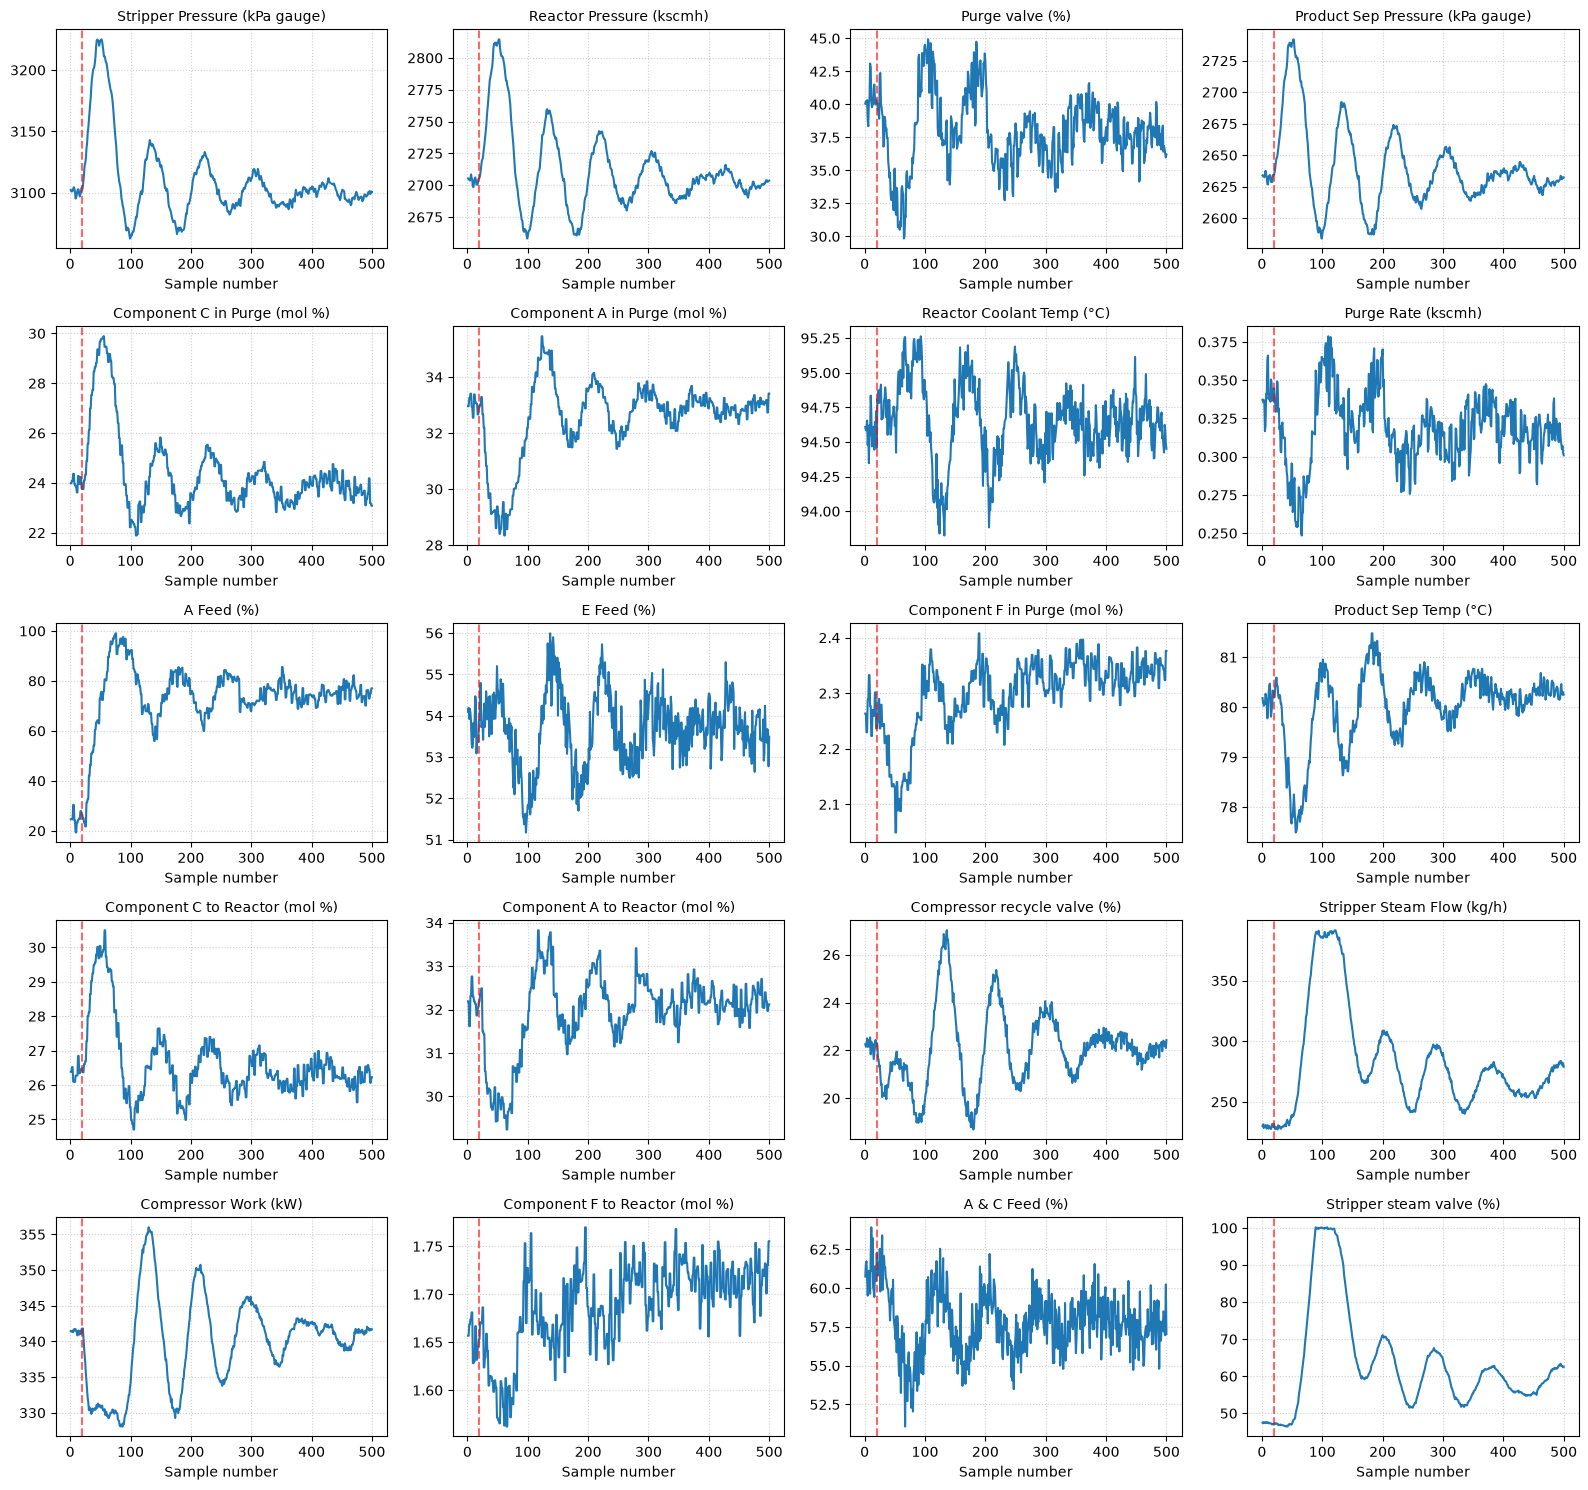


Analysis for B composition, A/C ratio constant Step (fault 2) in run 4


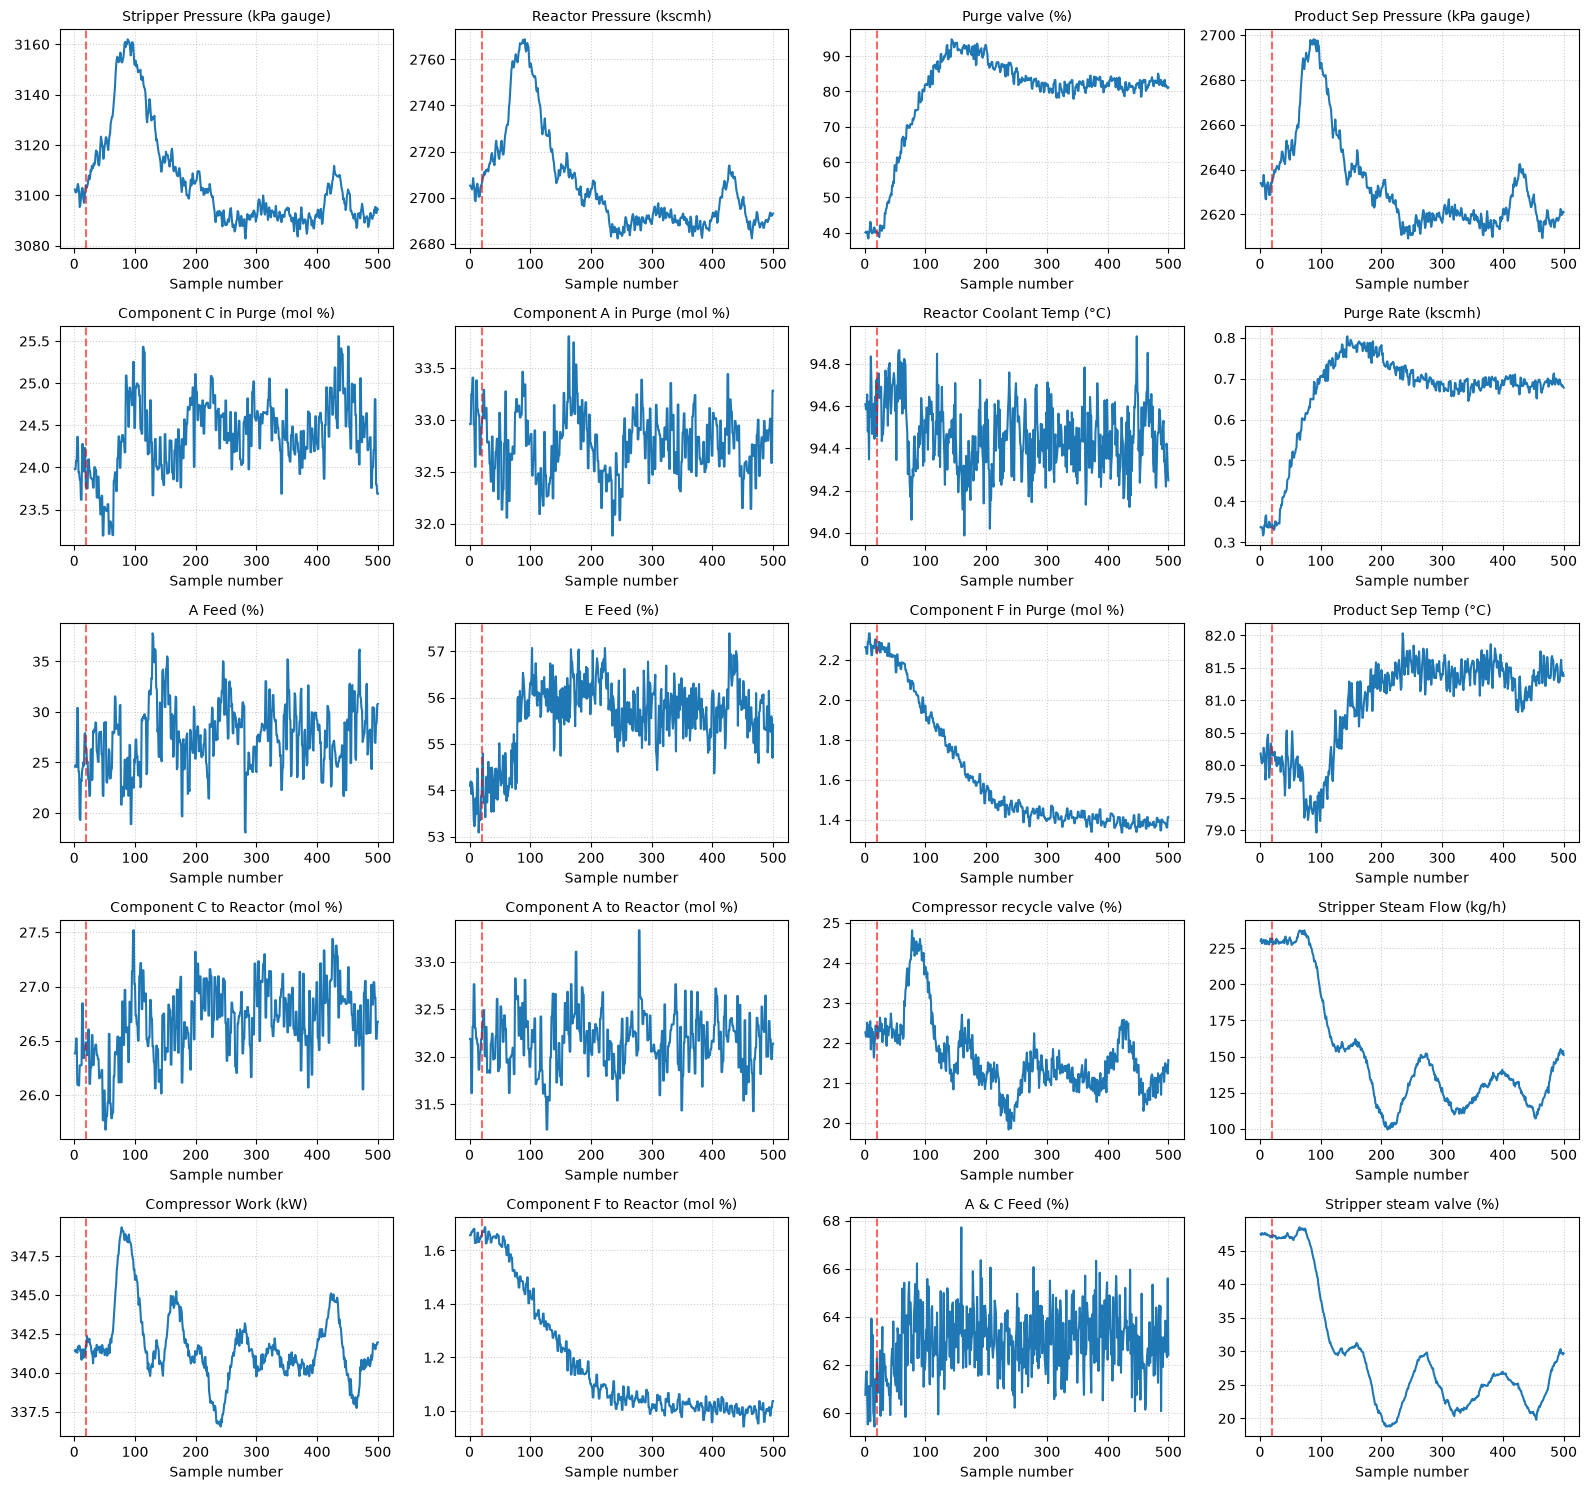


Analysis for A feed loss Step (fault 6) in run 4


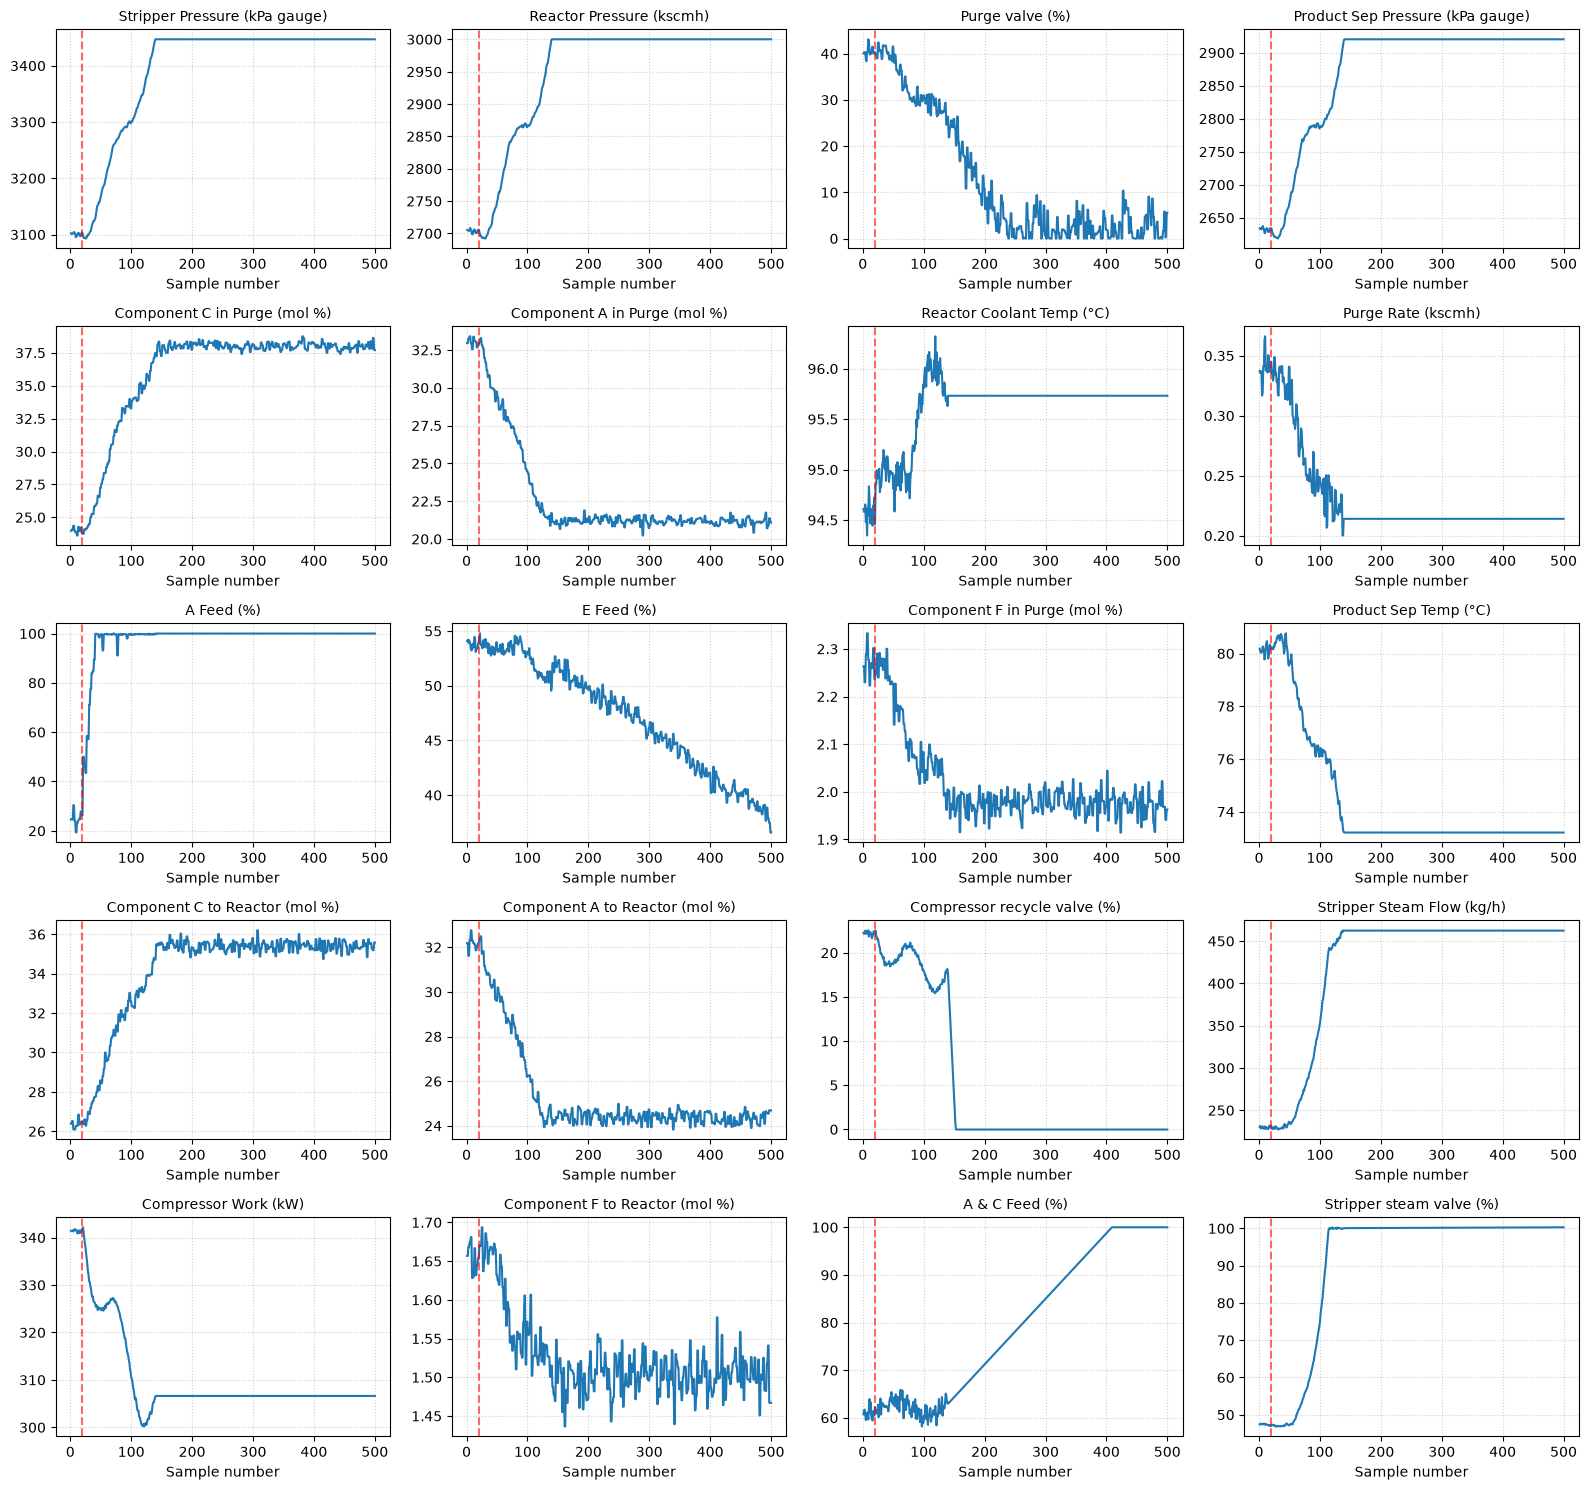


Analysis for Unknown (fault 18) in run 4


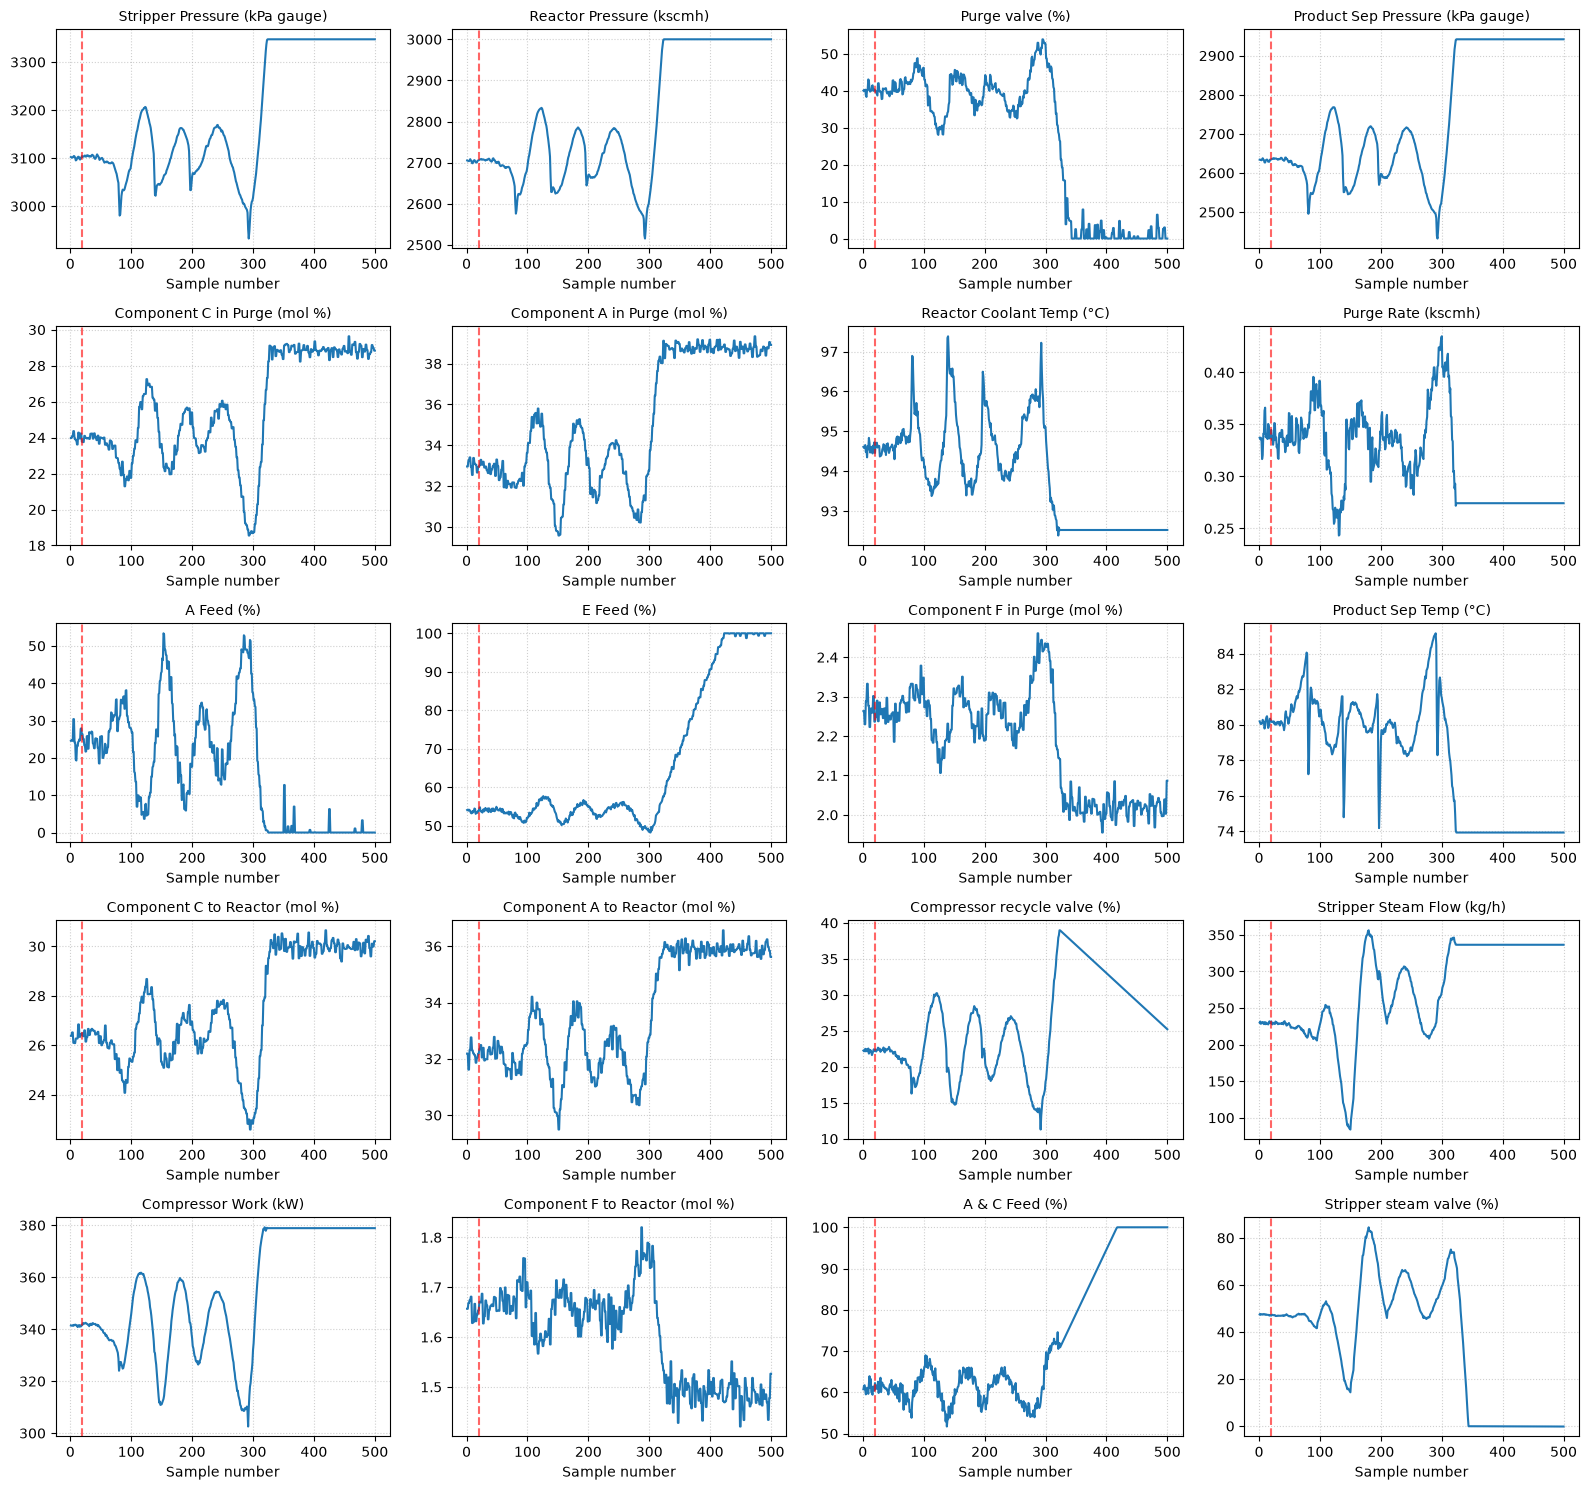

In [15]:
plot_variables(fault_numbers=[1,2,6,18], simulation_run= 4, variables = top_vars)

## Statistical Distribution Analysis
We utilize box plots to examine the statistical distribution of process variables in a single specified simulation for a specific fault, allowing us to characterize the "signature" of each fault type.

In [16]:
def plot_fault_distribution(fault_numbers, simulation_run=1, variables=None):
    """
    Creates box plots to visualize the distribution of process variables.
    
    Parameters:
    - fault_numbers (int or list): The fault ID(s) to analyze.
    - simulation_run (int, optional): The specific simulation run to plot. 
    - variables (list, optional): List of process variable names to analyze. 
      Defaults to all 52 process variables.
    """
    # If variables are not specified, use the global variable list
    if variables is None:
        variables = df_faulty_train.columns.drop(['faultNumber', 'simulationRun', 'sample']).tolist() 
        
    # If fault_numbers is a single integer, convert it into a list
    if isinstance(fault_numbers, int):
        fault_numbers = [fault_numbers]
        
    if simulation_run not in df_faulty_train['simulationRun'].unique():
        print(f"Simulation run {simulation_run} non trovato, uso il primo disponibile.")
        return
        
    num_features = len(variables)
    num_cols = min(4, num_features)
    num_rows = (num_features // num_cols) + (1 if num_features % num_cols != 0 else 0)
        
    for f_id in fault_numbers:
        fault_name = faults_mapping.get(f_id, f"Fault {f_id}")
        
        print(f'\nVariable distribution analysis for {fault_name} (fault {f_id}) in run {simulation_run}')
        
        data = df_faulty_train[df_faulty_train['faultNumber'] == f_id]
        
        data = data[data['simulationRun'] == simulation_run]

        
        # Prepare the plot grid
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
        
        # Flatten axes array for easy iteration
        if num_features == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for i, var in enumerate(variables):
            sns.boxplot(data=data, y=var, ax=axes[i]) 
            axes[i].set_title(var, fontsize=10)
            axes[i].grid(True, linestyle=':', alpha=0.5)
        
        # Remove empty subplots if any
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()


Variable distribution analysis for A/C feed ratio, B composition constant Step (fault 1) in run 90


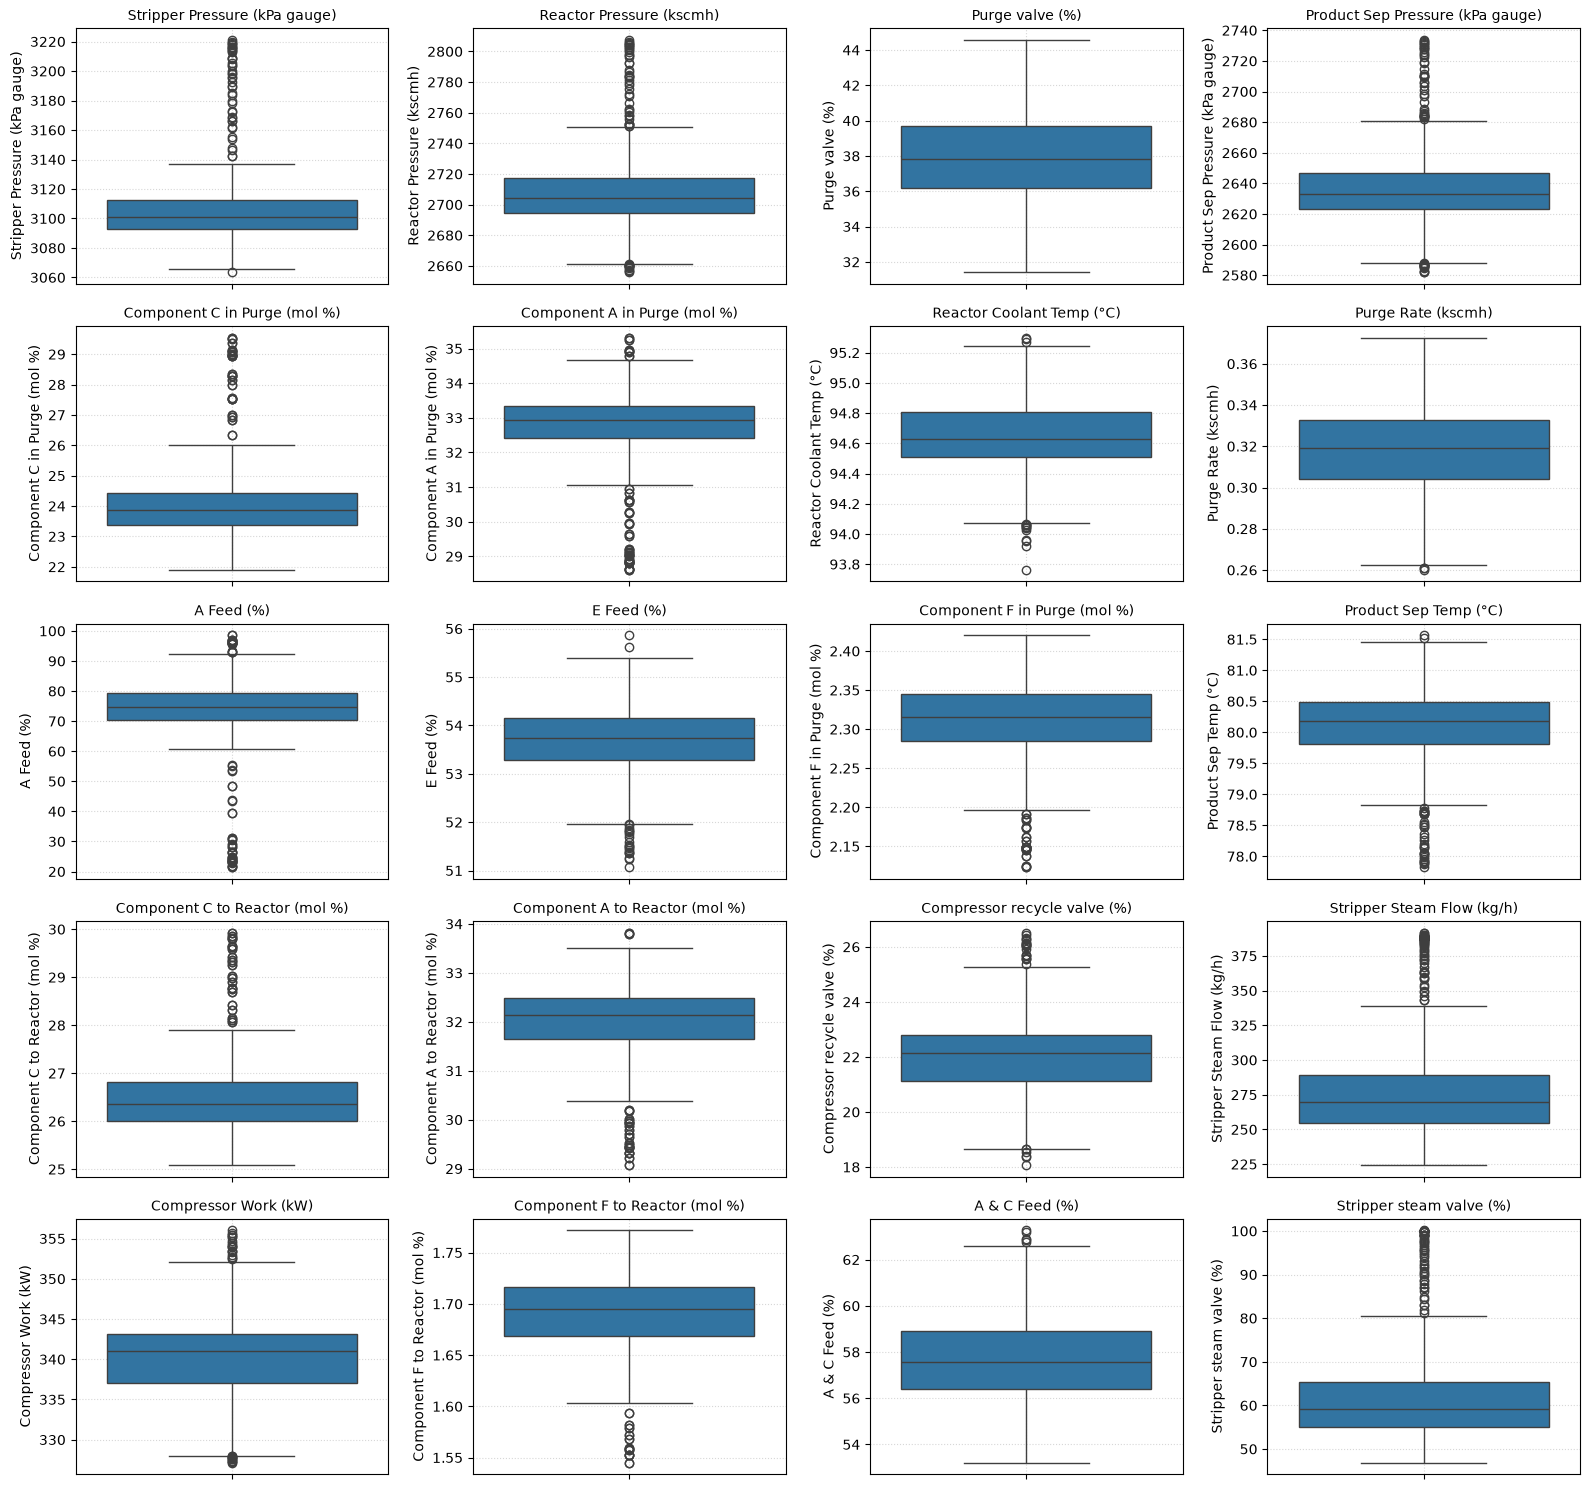


Variable distribution analysis for B composition, A/C ratio constant Step (fault 2) in run 90


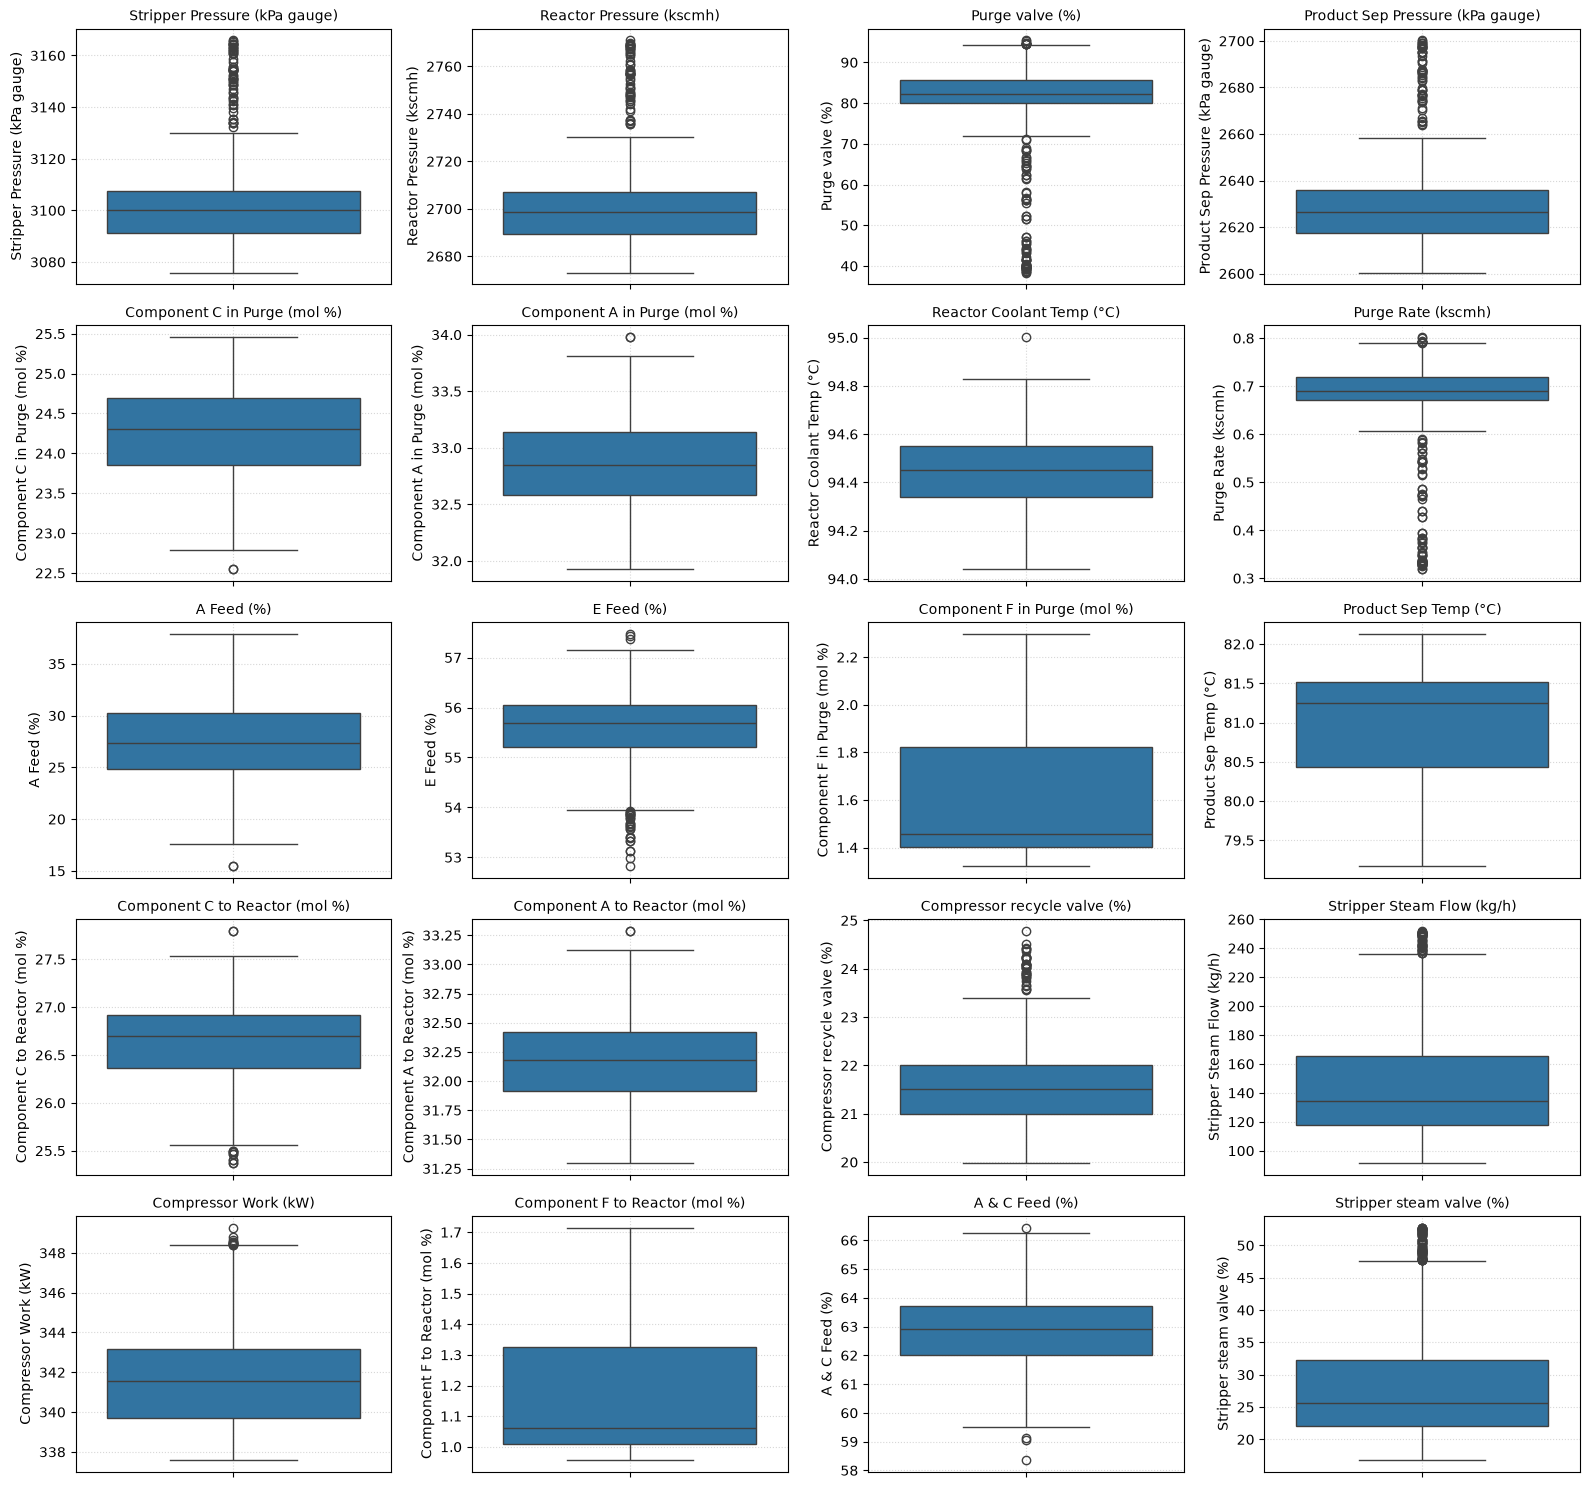


Variable distribution analysis for A feed loss Step (fault 6) in run 90


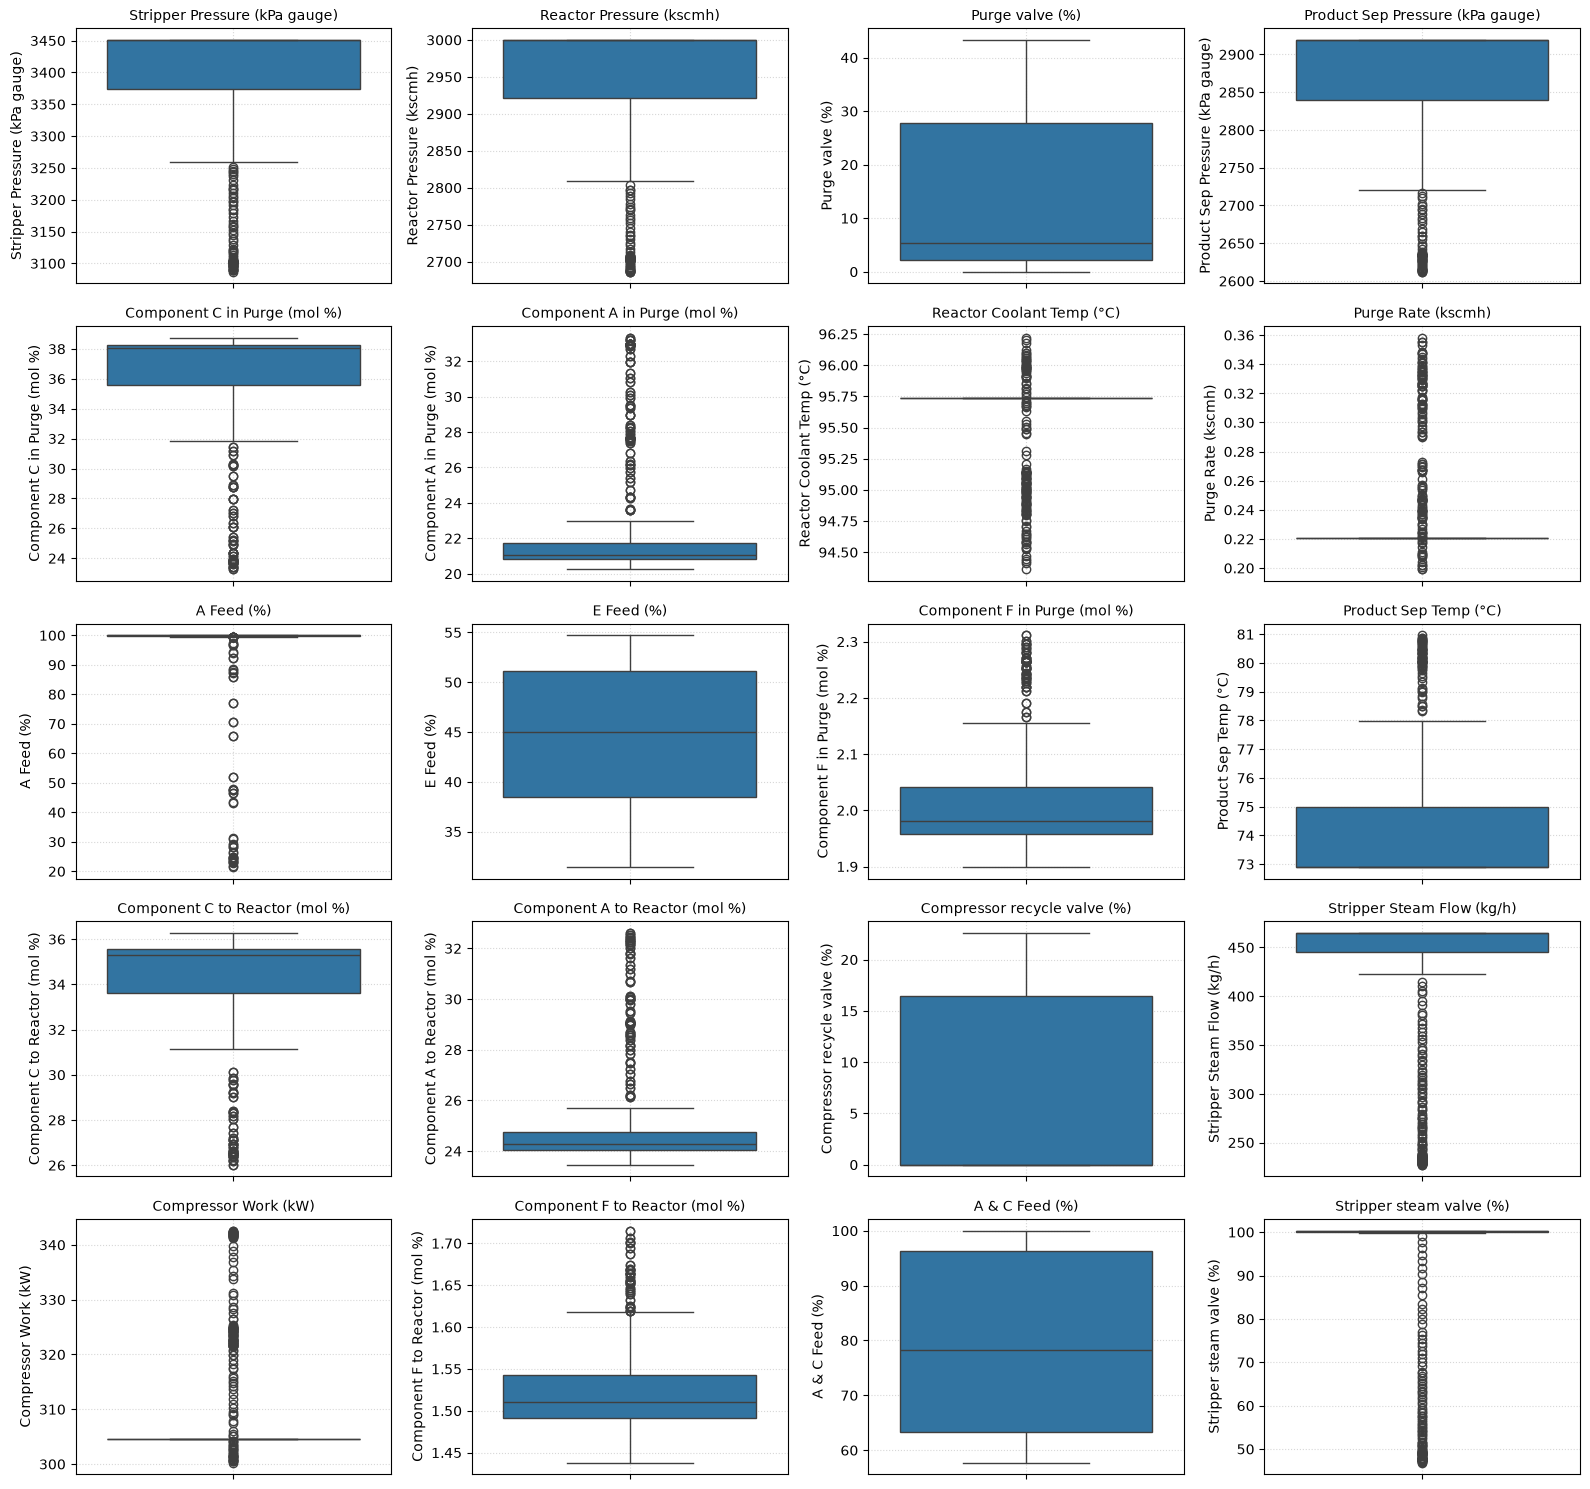


Variable distribution analysis for Unknown (fault 18) in run 90


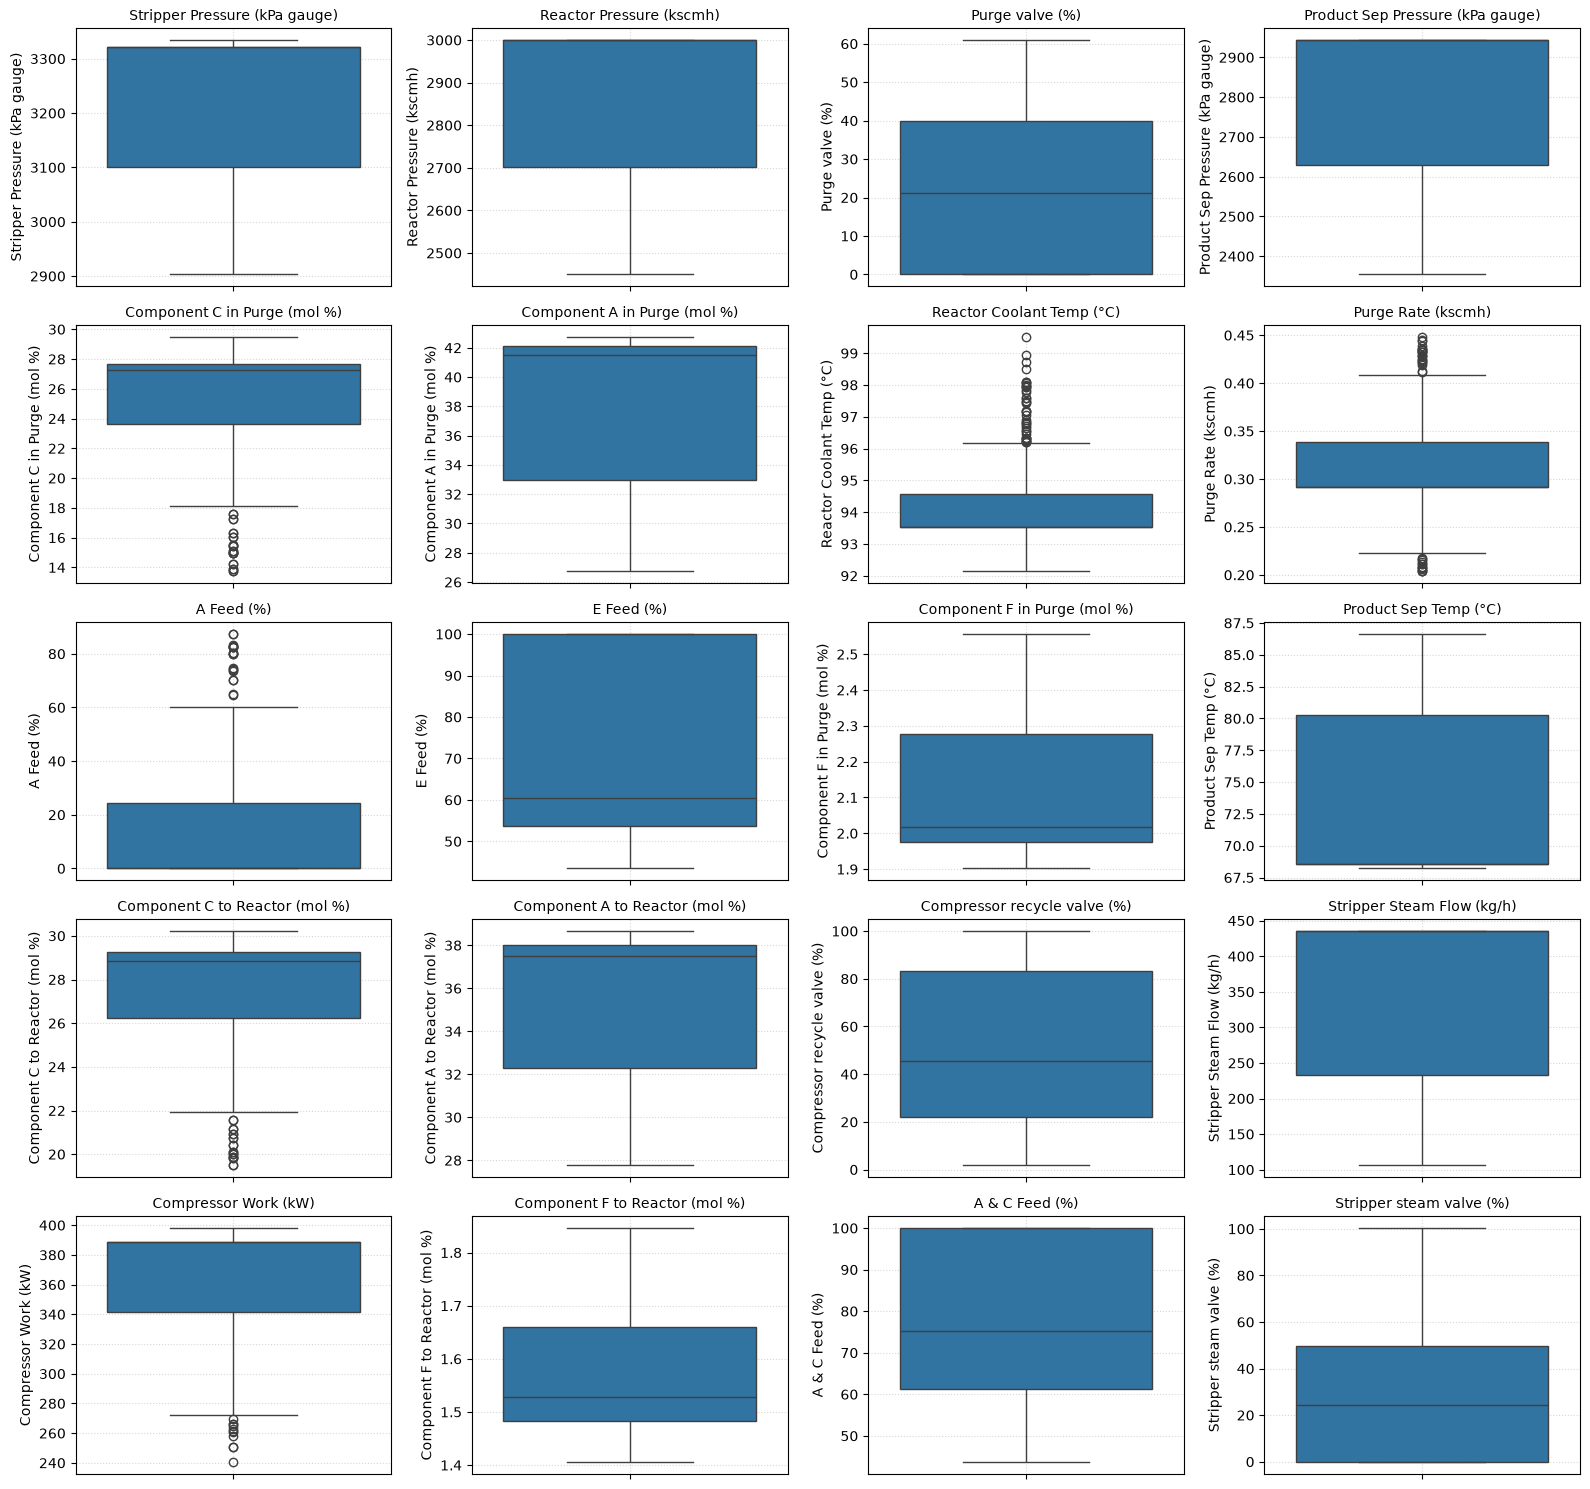

In [17]:
plot_fault_distribution(fault_numbers=[1,2,6,18], simulation_run=90, variables = top_vars)